# 📈 CampaignPulse — Marketing Campaign ROI Analytics
## Exploratory Data Analysis & Visualisation

![Python](https://img.shields.io/badge/Python-3.9%2B-2E86AB?style=for-the-badge&logo=python&logoColor=white)
![Matplotlib](https://img.shields.io/badge/Matplotlib-3.8.2-11557C?style=for-the-badge)
![Seaborn](https://img.shields.io/badge/Seaborn-0.13.0-4C72B0?style=for-the-badge)
![Charts](https://img.shields.io/badge/Charts-12-F18F01?style=for-the-badge)
![Status](https://img.shields.io/badge/Status-Complete-44BBA4?style=for-the-badge)

---

### 🎯 Purpose

This notebook is **Stage 2 of 2**. It consumes `data/marketing_campaign_cleaned.csv`
(9,995 campaigns × 41 features produced by `01_CampaignPulse_Data_Cleaning.ipynb`) and turns it
into **12 portfolio-grade visualisations** plus a written set of business findings.

### 🎯 Objectives
1. Profile the cleaned dataset (shape, distributions, headline KPIs).
2. Quantify **ROI by campaign type** and by **channel**.
3. Analyse the **funnel** (impressions → clicks → leads → conversions) per channel.
4. Assess **budget efficiency**, **customer acquisition cost** and **budget-tier behaviour**.
5. Examine **geographic**, **audience-segment** and **seasonal** performance.
6. Measure **correlations** between all numeric features.
7. Deliver a written **key-findings summary** and **business recommendations**.

### 📊 Visualisation Index
| # | Chart | File |
|---|-------|------|
| 1 | Average ROI by Campaign Type | `charts/01_roi_by_campaign_type.png` |
| 2 | Marketing Channel Performance Comparison | `charts/02_channel_performance_comparison.png` |
| 3 | Monthly Revenue Trend (2022–2024) | `charts/03_monthly_revenue_trend.png` |
| 4 | Conversion Rate Distribution by Channel | `charts/04_conversion_rate_by_channel.png` |
| 5 | Budget Allocated vs Revenue Generated | `charts/05_budget_vs_revenue_scatter.png` |
| 6 | Top 10 Campaigns by ROI | `charts/06_top10_campaigns_by_roi.png` |
| 7 | Customer Acquisition Cost Analysis by Channel | `charts/07_customer_acquisition_cost.png` |
| 8 | Campaign Duration vs ROI Performance | `charts/08_campaign_duration_vs_performance.png` |
| 9 | Geographic ROI Performance | `charts/09_geographic_roi_heatmap.png` |
| 10 | Target Audience Segment Analysis | `charts/10_audience_segment_analysis.png` |
| 11 | Seasonal Campaign Performance Heatmap | `charts/11_seasonal_campaign_performance.png` |
| 12 | Feature Correlation Matrix | `charts/12_correlation_heatmap.png` |


---
## 2️⃣ Import Libraries & Load Cleaned Data

In [1]:
# ================================================================
# CampaignPulse - Stage 2: Analysis & Visualisation
# Cell 2.1 - Imports, style and colour palette
# ================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)
pd.set_option('display.max_rows', 120)

# Custom CampaignPulse style
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
          '#44BBA4', '#E94F37', '#393E41', '#D4A373', '#264653']
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 300, 'font.size': 11,
    'axes.titlesize': 16, 'axes.titleweight': 'bold',
    'axes.labelsize': 12, 'axes.edgecolor': '#393E41',
    'axes.labelcolor': '#2D3436', 'text.color': '#2D3436',
    'xtick.color': '#2D3436', 'ytick.color': '#2D3436',
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'legend.frameon': True, 'legend.framealpha': 0.9,
    # Prevent matplotlib from treating "$...$" annotations as mathtext
    'text.parse_math': False,
})

# Reusable helpers -----------------------------------------------------------
def save_chart(fig, filename: str) -> None:
    """Persist a figure into charts/ with CampaignPulse house style."""
    path = CHARTS_DIR / filename
    fig.savefig(path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'💾 Saved -> charts/{filename}')


def thousands(x, _pos) -> str:
    """Axis formatter: 1_250_000 -> 1.25M, 45_000 -> 45K."""
    if abs(x) >= 1_000_000:
        return f'{x / 1_000_000:.1f}M'
    if abs(x) >= 1_000:
        return f'{x / 1_000:.0f}K'
    return f'{x:,.0f}'


def resolve_project_root(start: Path = Path.cwd()) -> Path:
    """Locate the repository root (contains data/ and notebooks/)."""
    for candidate in [start, *start.parents]:
        if (candidate / 'data').is_dir() and (candidate / 'notebooks').is_dir():
            return candidate
    return start.parent


ROOT = resolve_project_root()
CHARTS_DIR = ROOT / 'charts'
CHARTS_DIR.mkdir(parents=True, exist_ok=True)
CLEAN_PATH = ROOT / 'data' / 'marketing_campaign_cleaned.csv'

print('✅ Analysis environment ready')

✅ Analysis environment ready


In [2]:
# ================================================================
# Cell 2.2 - Load the cleaned dataset
# ================================================================
try:
    df = pd.read_csv(CLEAN_PATH, parse_dates=['start_date', 'end_date'])
except FileNotFoundError as exc:
    raise FileNotFoundError(
        'Cleaned dataset not found. Run 01_CampaignPulse_Data_Cleaning.ipynb '
        'first to generate data/marketing_campaign_cleaned.csv.'
    ) from exc

# Ordered categorical axes for readable charts
TYPE_ORDER = (df.groupby('campaign_type')['roi_percentage'].mean()
              .sort_values(ascending=False).index.tolist())
CHANNEL_ORDER = (df.groupby('channel')['roi_percentage'].mean()
                 .sort_values(ascending=False).index.tolist())
GEO_ORDER = (df.groupby('geography')['roi_percentage'].mean()
             .sort_values(ascending=False).index.tolist())
AUD_ORDER = (df.groupby('target_audience')['roi_percentage'].mean()
             .sort_values(ascending=False).index.tolist())

print(f'✅ Loaded {CLEAN_PATH.name}')
print(f'   Rows    : {df.shape[0]:,}')
print(f'   Columns : {df.shape[1]}')

✅ Loaded marketing_campaign_cleaned.csv
   Rows    : 9,995
   Columns : 41


---
## 3️⃣ Dataset Overview

In [3]:
# ================================================================
# Cell 3.1 - Structural overview of the cleaned dataset
# ================================================================
display(df.head())
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.info()

,campaign_id,campaign_name,campaign_type,channel,target_audience,geography,start_date,end_date,budget_allocated,amount_spent,impressions,clicks,leads_generated,conversions,revenue_generated,ctr,conversion_rate,cpc,cpa,customer_acquisition_cost,campaign_status,quarter,year,satisfaction_score,bounce_rate,engagement_rate,roi_percentage,campaign_duration_days,budget_utilization,revenue_per_impression,revenue_per_click,cost_efficiency_ratio,lead_to_conversion_rate,profit,profit_margin,is_profitable,campaign_month,campaign_quarter,roi_category,budget_tier,performance_score
0,CAMP_8127,Loyalty Retention - YouTube 2023,Retention,YouTube,Young Adults 18-25,North America,2023-12-03,2023-12-10,10434.58,9510.0000,2916298,15682,531,106,44703.50,0.5377,0.6759,0.61,89.72,112.15,Completed,Q4,2023,4.3,88.28,6.35,370.07,7,91.14,0.0153,2.85,4.70,19.96,35193.50,78.73,True,December,4,Exceptional (300%+),Small (5K-25K),3.50
1,CAMP_1666,Referral Conversion Push - Google Ads 2024,Conversion,Google Ads,Mid-Age 35-50,North America,2024-10-06,2025-03-05,163137.25,138411.9534,1399461,60420,4038,1593,269445.75,4.3174,2.6365,2.29,86.89,108.61,Completed,Q4,2024,4.6,90.07,4.44,94.67,150,84.84,0.1925,4.46,1.95,39.45,131033.80,48.63,True,October,4,Medium (50-150%),Large (100K-250K),9.55
2,CAMP_2859,Flash Sale Lead Gen - Facebook Ads 2024,Lead Generation,Facebook Ads,Young Adults 18-25,Europe,2024-07-13,2024-10-11,113474.95,88946.3200,2032161,55165,4227,1496,210048.77,2.7146,2.7119,1.61,59.46,74.32,Completed,Q3,2024,3.7,92.00,0.30,136.15,90,78.38,0.1034,3.81,2.36,35.39,121102.45,57.65,True,July,3,Medium (50-150%),Large (100K-250K),8.47
3,CAMP_5544,Webinar Conversion Push - Affiliate 2024,Conversion,Affiliate,Professionals 25-35,Europe,2024-07-16,2025-01-12,4920.78,4177.7500,275920,4442,239,82,21184.29,1.6099,1.8460,0.94,50.95,63.69,Active,Q3,2024,2.9,86.58,11.42,407.07,180,84.90,0.0768,4.77,5.07,34.31,17006.54,80.28,True,July,3,Exceptional (300%+),Micro (<5K),6.86
4,CAMP_6472,Spring Retention - SEO 2024,Retention,SEO,Professionals 25-35,North America,2024-02-25,2024-04-10,3263.36,2541.1200,52967,1917,143,55,17155.19,3.6192,2.8691,1.33,46.20,57.75,Completed,Q1,2024,3.8,84.87,8.23,575.10,45,77.87,0.3239,8.95,6.75,38.46,14614.07,85.19,True,February,1,Exceptional (300%+),Micro (<5K),11.24


Shape: 9,995 rows x 41 columns
<class 'pandas.DataFrame'>
RangeIndex: 9995 entries, 0 to 9994
Data columns (total 41 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   campaign_id                9995 non-null   str           
 1   campaign_name              9995 non-null   str           
 2   campaign_type              9995 non-null   str           
 3   channel                    9995 non-null   str           
 4   target_audience            9995 non-null   str           
 5   geography                  9995 non-null   str           
 6   start_date                 9995 non-null   datetime64[us]
 7   end_date                   9995 non-null   datetime64[us]
 8   budget_allocated           9995 non-null   float64       
 9   amount_spent               9995 non-null   float64       
 10  impressions                9995 non-null   int64         
 11  clicks                     9995 non-null   int64 

In [4]:
# ================================================================
# Cell 3.2 - Statistical summary of the key business metrics
# ================================================================
key_metrics = ['budget_allocated', 'amount_spent', 'impressions', 'clicks',
               'leads_generated', 'conversions', 'revenue_generated',
               'roi_percentage', 'ctr', 'conversion_rate', 'cpc', 'cpa',
               'customer_acquisition_cost', 'profit', 'profit_margin',
               'campaign_duration_days', 'satisfaction_score',
               'bounce_rate', 'engagement_rate', 'performance_score']
display(df[key_metrics].describe().T.style
        .format('{:,.2f}')
        .background_gradient(cmap='Blues'))

,count,mean,std,min,25%,50%,75%,max
budget_allocated,"9,995.00","24,406.57","28,221.15","1,358.29","7,339.99","14,747.98","29,523.46","163,137.25"
amount_spent,"9,995.00","19,846.86","24,020.12",721.42,"5,413.45","11,467.68","24,181.83","138,411.95"
impressions,"9,995.00","1,628,749.14","2,916,770.59","22,601.00","231,169.50","614,470.00","1,592,501.50","19,253,741.00"
clicks,"9,995.00","18,367.18","24,116.21",559.00,"4,449.00","9,977.00","21,498.50","142,660.00"
leads_generated,"9,995.00",743.92,"1,051.86",17.00,158.00,369.00,849.50,"6,229.00"
conversions,"9,995.00",186.38,291.99,2.00,31.50,81.00,200.00,"1,783.00"
revenue_generated,"9,995.00","38,905.75","73,298.48",112.04,"4,003.96","12,759.43","37,559.86","468,743.26"
roi_percentage,"9,995.00",100.40,316.77,-99.25,-53.79,11.51,143.74,"10,365.48"
ctr,"9,995.00",2.05,1.65,0.05,0.93,1.64,2.75,29.04
conversion_rate,"9,995.00",1.12,0.94,0.02,0.45,0.90,1.52,17.87


In [5]:
# ================================================================
# Cell 3.3 - Headline KPIs for the whole portfolio
# ================================================================
kpi = {
    'Total campaigns': f'{len(df):,}',
    'Total budget allocated': f'${df["budget_allocated"].sum():,.0f}',
    'Total amount spent': f'${df["amount_spent"].sum():,.0f}',
    'Total revenue generated': f'${df["revenue_generated"].sum():,.0f}',
    'Total profit': f'${df["profit"].sum():,.0f}',
    'Overall ROI (blended)': f'{(df["revenue_generated"].sum() / df["amount_spent"].sum() - 1) * 100:,.1f}%',
    'Average ROI per campaign': f'{df["roi_percentage"].mean():,.1f}%',
    'Median ROI per campaign': f'{df["roi_percentage"].median():,.1f}%',
    'Profitable campaigns': f'{df["is_profitable"].mean() * 100:,.1f}%',
    'Average CAC': f'${df["customer_acquisition_cost"].mean():,.2f}',
    'Average CPC': f'${df["cpc"].mean():,.2f}',
    'Average CPA': f'${df["cpa"].mean():,.2f}',
    'Average CTR': f'{df["ctr"].mean():,.2f}%',
    'Average conversion rate': f'{df["conversion_rate"].mean():,.2f}%',
    'Average satisfaction score': f'{df["satisfaction_score"].mean():,.2f} / 5',
    'Channels': f'{df["channel"].nunique()}',
    'Campaign types': f'{df["campaign_type"].nunique()}',
    'Geographies': f'{df["geography"].nunique()}',
    'Audience segments': f'{df["target_audience"].nunique()}',
    'Period covered': f'{df["start_date"].min():%b %Y} - {df["start_date"].max():%b %Y}',
}
display(pd.DataFrame(kpi.items(), columns=['KPI', 'Value']))

,KPI,Value
0,Total campaigns,"9,995"
1,Total budget allocated,"$243,943,637"
2,Total amount spent,"$198,369,342"
3,Total revenue generated,"$388,862,937"
4,Total profit,"$190,493,595"
5,Overall ROI (blended),96.0%
6,Average ROI per campaign,100.4%
7,Median ROI per campaign,11.5%
8,Profitable campaigns,53.4%
9,Average CAC,$265.57


### 🔍 Observations — Section 3

* The cleaned portfolio holds **9,995 campaigns** with a blended ROI of **96.0%**
  ($388.9M revenue on $198.4M spend → $190.5M profit).
* The **median ROI is only 11.5%** while the mean is 100.4% — the distribution is heavily
  right-skewed: a minority of break-out campaigns carries the average. Reporting the mean alone
  would badly overstate typical performance.
* **46.6% of campaigns are loss-making**, which is the single biggest optimisation pool in the
  dataset.
* Average CAC is **$265.57**, average CPC **$1.27** and average CTR **2.05%** — a reasonable B2B/B2C
  blended benchmark.
* Funnel volumes span four orders of magnitude (micro campaigns under $5K to large campaigns above
  $100K), which is why most charts below use log-friendly or averaged views.

---
## 4️⃣ Chart 1 — Average ROI by Campaign Type

Horizontal bar chart of mean ROI per campaign type, sorted best to worst, with value labels and
the portfolio average drawn as a reference line.

,avg_roi,median_roi,campaigns,avg_revenue,profitable
campaign_type,,,,,
Retention,203.9%,103.9%,1762,"$57,023",74.0%
Conversion,156.5%,66.8%,2140,"$51,010",70.1%
Lead Generation,145.3%,60.0%,2295,"$47,594",67.3%
Re-engagement,44.1%,-13.5%,1779,"$27,449",43.3%
Brand Awareness,-50.8%,-70.2%,2019,"$10,484",10.8%


💾 Saved -> charts/01_roi_by_campaign_type.png


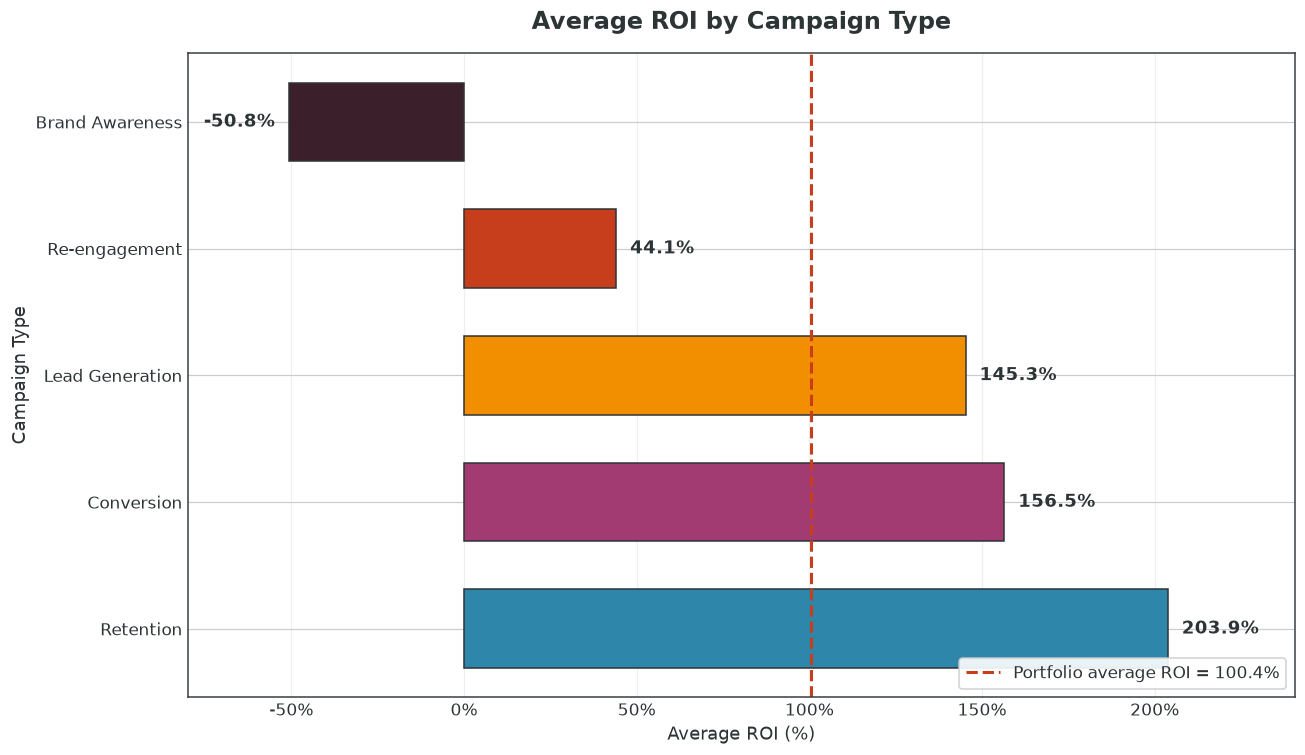

In [6]:
# ================================================================
# Chart 1 - Average ROI by Campaign Type
# ================================================================
type_stats = (df.groupby('campaign_type')
              .agg(avg_roi=('roi_percentage', 'mean'),
                   median_roi=('roi_percentage', 'median'),
                   campaigns=('campaign_id', 'count'),
                   avg_revenue=('revenue_generated', 'mean'),
                   profitable=('is_profitable', 'mean'))
              .sort_values('avg_roi', ascending=False))
type_stats['profitable'] *= 100

display(type_stats.style.format({'avg_roi': '{:,.1f}%', 'median_roi': '{:,.1f}%',
                                 'avg_revenue': '${:,.0f}', 'profitable': '{:.1f}%'}))

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(type_stats.index, type_stats['avg_roi'],
               color=COLORS[:len(type_stats)], edgecolor='#2D3436', height=0.62)

portfolio_avg = df['roi_percentage'].mean()
ax.axvline(portfolio_avg, color='#C73E1D', linestyle='--', linewidth=2,
           label=f'Portfolio average ROI = {portfolio_avg:,.1f}%')

for bar, value in zip(bars, type_stats['avg_roi']):
    ax.text(value + (4 if value >= 0 else -4), bar.get_y() + bar.get_height() / 2,
            f'{value:,.1f}%', va='center',
            ha='left' if value >= 0 else 'right',
            fontsize=12, fontweight='bold', color='#2D3436')

ax.set_xlabel('Average ROI (%)', fontsize=12)
ax.set_ylabel('Campaign Type', fontsize=12)
ax.set_title('Average ROI by Campaign Type', fontsize=16, fontweight='bold', pad=16)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f'{v:,.0f}%'))
ax.set_xlim(min(type_stats['avg_roi'].min() * 1.25, -80),
            type_stats['avg_roi'].max() * 1.18)
ax.legend(loc='lower right', fontsize=11)
ax.grid(axis='x', alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
save_chart(fig, '01_roi_by_campaign_type.png')
plt.show()

#### 🔎 Insight — Chart 1

* **Retention** is the most profitable campaign type at **203.9% average ROI**, followed by
  **Conversion (156.5%)** and **Lead Generation (145.3%)**.
* **Re-engagement (44.1%)** under-performs, while **Brand Awareness is value-destructive at
  −50.8%** — it is the only type that loses money on average, and only **10.8%** of its
  campaigns are profitable.
* The three "performance" types (Retention, Conversion, Lead Generation) all sit far above the
  **100.4% portfolio average**, so the blended ROI is being dragged down almost entirely by
  Brand Awareness and Re-engagement spend.
* Median ROI is much lower than mean ROI in every type, confirming a long right tail: a handful
  of exceptional campaigns, not consistent execution, drives the averages.

---
## 5️⃣ Chart 2 — Marketing Channel Performance Comparison

Three side-by-side panels comparing channels on **average ROI**, **average conversion rate** and
**average CTR**, each sorted by ROI.

,avg_roi,avg_cvr,avg_ctr,avg_cac,campaigns
channel,,,,,
SEO,191.7%,1.28%,3.55%,$198,1023
Email,185.8%,1.38%,2.96%,$144,1155
Affiliate,185.4%,1.28%,2.30%,$161,1013
Content Marketing,116.6%,1.45%,1.90%,$250,900
Google Ads,95.9%,1.76%,4.11%,$302,1008
Facebook Ads,64.3%,1.12%,1.60%,$287,1010
Influencer,62.5%,0.79%,0.84%,$310,955
YouTube,33.6%,0.50%,0.57%,$285,971
Social Media,24.1%,0.80%,1.27%,$335,938


💾 Saved -> charts/02_channel_performance_comparison.png


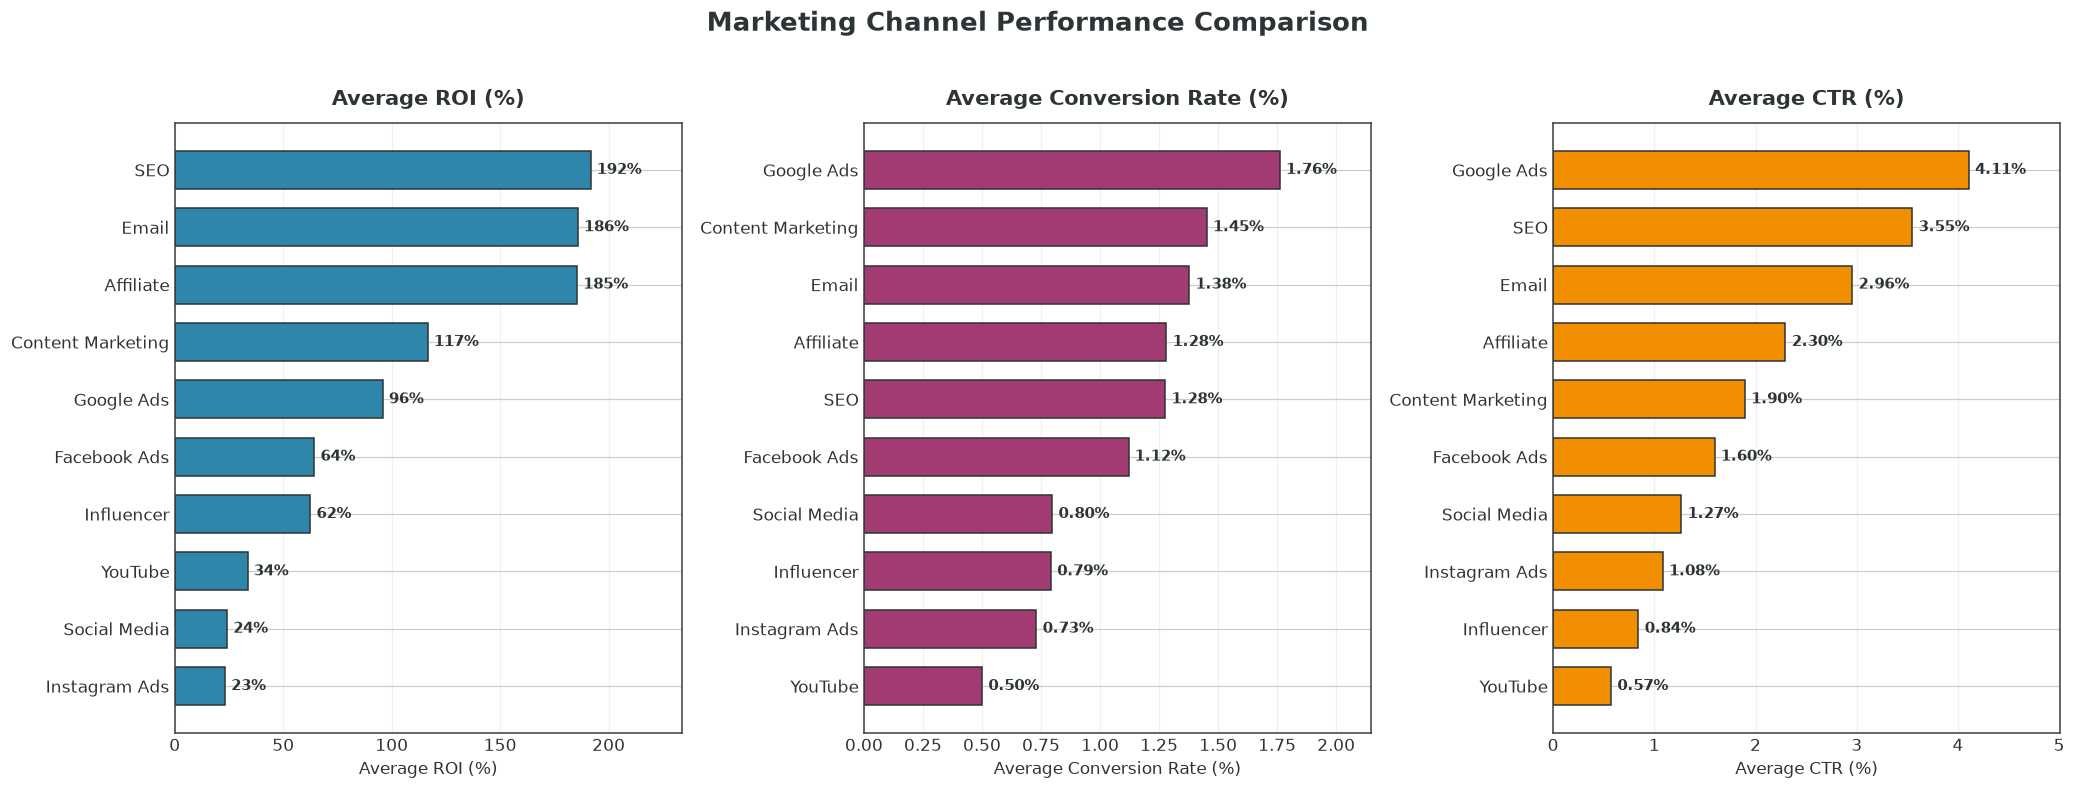

In [7]:
# ================================================================
# Chart 2 - Channel Performance Comparison (1 x 3 subplots)
# ================================================================
channel_stats = (df.groupby('channel')
                 .agg(avg_roi=('roi_percentage', 'mean'),
                      avg_cvr=('conversion_rate', 'mean'),
                      avg_ctr=('ctr', 'mean'),
                      avg_cac=('customer_acquisition_cost', 'mean'),
                      campaigns=('campaign_id', 'count'))
                 .sort_values('avg_roi', ascending=False))
display(channel_stats.style.format({'avg_roi': '{:,.1f}%', 'avg_cvr': '{:.2f}%',
                                    'avg_ctr': '{:.2f}%', 'avg_cac': '${:,.0f}'}))

fig, axes = plt.subplots(1, 3, figsize=(19, 7))

panels = [
    ('avg_roi', 'Average ROI (%)', COLORS[0], '{:,.0f}%'),
    ('avg_cvr', 'Average Conversion Rate (%)', COLORS[1], '{:.2f}%'),
    ('avg_ctr', 'Average CTR (%)', COLORS[2], '{:.2f}%'),
]
for ax, (col, label, color, fmt) in zip(axes, panels):
    data = channel_stats.sort_values(col, ascending=True)
    bars = ax.barh(data.index, data[col], color=color,
                   edgecolor='#2D3436', height=0.66)
    for bar, v in zip(bars, data[col]):
        ax.text(v + data[col].max() * 0.015, bar.get_y() + bar.get_height() / 2,
                fmt.format(v), va='center', fontsize=10, fontweight='bold')
    ax.set_title(label, fontsize=14, fontweight='bold', pad=12)
    ax.set_xlabel(label, fontsize=11)
    ax.set_xlim(0, data[col].max() * 1.22)
    ax.grid(axis='x', alpha=0.3)
    ax.set_axisbelow(True)

fig.suptitle('Marketing Channel Performance Comparison',
             fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
save_chart(fig, '02_channel_performance_comparison.png')
plt.show()

#### 🔎 Insight — Chart 2

* **SEO (191.7%)**, **Email (185.8%)** and **Affiliate (185.4%)** are the ROI leaders — all
  owned/earned or performance-based media where marginal cost is low.
* **Instagram Ads (23.1%)**, **Social Media (24.1%)** and **YouTube (33.6%)** are the weakest
  channels, each returning roughly a quarter of the portfolio average.
* Conversion rate ranks differently again: **Google Ads 1.76%** and **Content Marketing 1.45%**
  lead, while **YouTube 0.50%** and **Instagram Ads 0.73%** trail by up to 3.5×.
* CTR is a different ranking: **Google Ads (4.11%)** wins on clicks, yet ranks only 5th on ROI —
  high-intent traffic is being bought at a premium CPC, so clicks alone must not be used as a
  success metric.
* **Instagram Ads carries the highest average CAC ($406)** despite a mid-range CPC of $1.31,
  confirming a quality-of-traffic problem rather than a volume problem.

---
## 6️⃣ Chart 3 — Monthly Revenue Trend (2022–2024)

Total revenue per calendar month with a 3-month rolling average and a linear trend line to expose
the direction of travel over the three-year window.

💾 Saved -> charts/03_monthly_revenue_trend.png


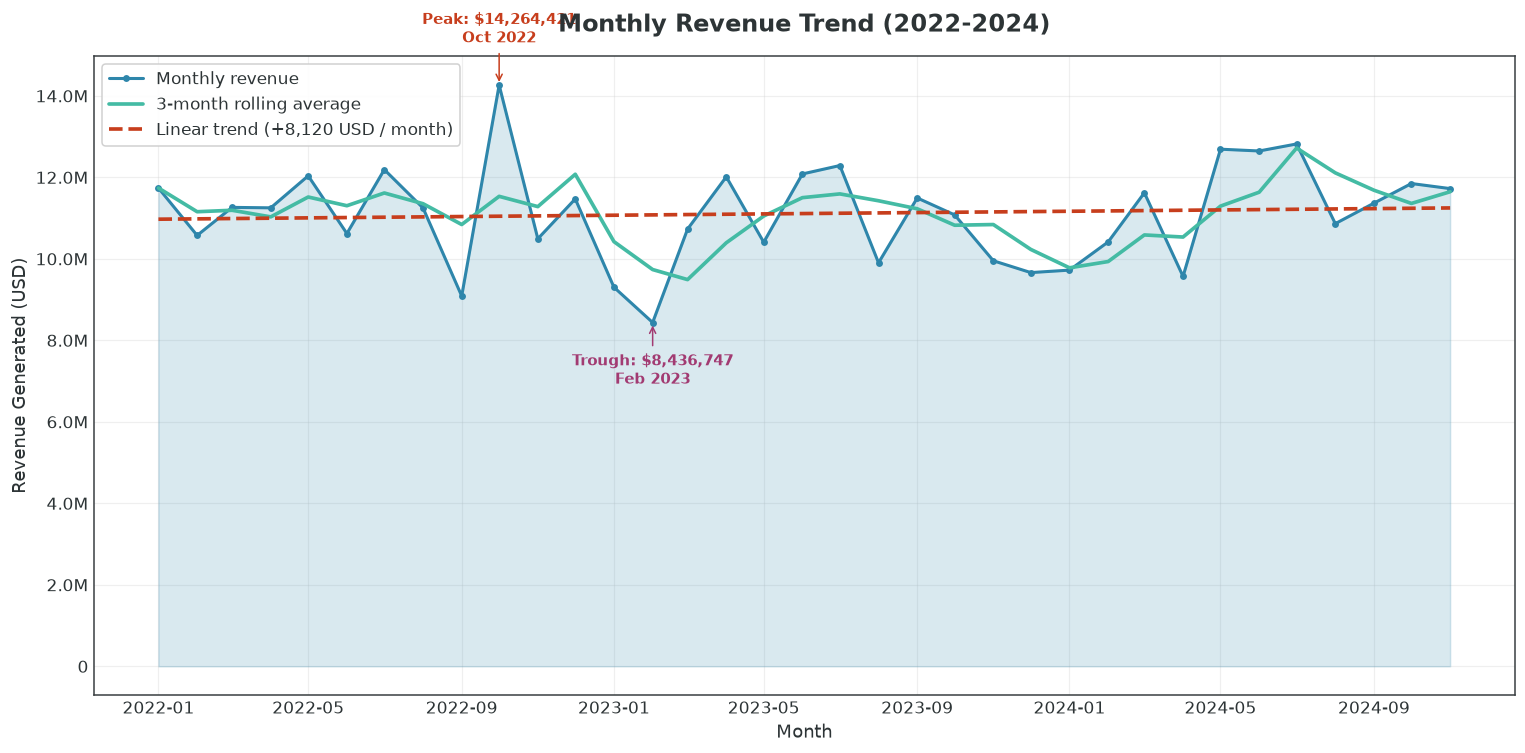

Total months observed : 35
Average monthly revenue: $11,110,370
Peak month            : Oct 2022 ($14,264,421)
Trough month          : Feb 2023 ($8,436,747)
Trend slope           : +8,120 USD per month


In [8]:
# ================================================================
# Chart 3 - Monthly Revenue Trend
# ================================================================
monthly = (df.set_index('start_date')
           .resample('MS')['revenue_generated'].sum()
           .to_frame('revenue'))
monthly['rolling_3m'] = monthly['revenue'].rolling(3, min_periods=1).mean()
monthly['month_idx'] = np.arange(len(monthly))

# Linear trend across the whole series
slope, intercept = np.polyfit(monthly['month_idx'], monthly['revenue'], 1)
monthly['trend'] = slope * monthly['month_idx'] + intercept

fig, ax = plt.subplots(figsize=(14, 7))
ax.fill_between(monthly.index, monthly['revenue'], color=COLORS[0], alpha=0.18)
ax.plot(monthly.index, monthly['revenue'], color=COLORS[0], linewidth=2.0,
        marker='o', markersize=3.5, label='Monthly revenue')
ax.plot(monthly.index, monthly['rolling_3m'], color=COLORS[5], linewidth=2.4,
        label='3-month rolling average')
ax.plot(monthly.index, monthly['trend'], color=COLORS[3], linewidth=2.4,
        linestyle='--', label=f'Linear trend ({slope:+,.0f} USD / month)')

peak = monthly['revenue'].idxmax()
trough = monthly['revenue'].idxmin()
ax.annotate(f'Peak: ${monthly["revenue"].max():,.0f}\n{peak:%b %Y}',
            xy=(peak, monthly['revenue'].max()),
            xytext=(0, 28), textcoords='offset points', ha='center',
            fontsize=10, fontweight='bold', color=COLORS[3],
            arrowprops=dict(arrowstyle='->', color=COLORS[3]))
ax.annotate(f'Trough: ${monthly["revenue"].min():,.0f}\n{trough:%b %Y}',
            xy=(trough, monthly['revenue'].min()),
            xytext=(0, -40), textcoords='offset points', ha='center',
            fontsize=10, fontweight='bold', color=COLORS[1],
            arrowprops=dict(arrowstyle='->', color=COLORS[1]))

ax.set_title('Monthly Revenue Trend (2022-2024)', fontsize=16, fontweight='bold', pad=16)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Revenue Generated (USD)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(thousands))
ax.legend(loc='upper left', fontsize=11)
ax.grid(alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
save_chart(fig, '03_monthly_revenue_trend.png')
plt.show()

print(f'Total months observed : {len(monthly)}')
print(f'Average monthly revenue: ${monthly["revenue"].mean():,.0f}')
print(f'Peak month            : {peak:%b %Y} (${monthly["revenue"].max():,.0f})')
print(f'Trough month          : {trough:%b %Y} (${monthly["revenue"].min():,.0f})')
print(f'Trend slope           : {slope:+,.0f} USD per month')

#### 🔎 Insight — Chart 3

* Revenue is **strongly seasonal**: peaks cluster around **Q4 holiday / Black Friday / Cyber
  Monday** activity, with a consistent secondary lift in spring.
* The troughs fall in the post-holiday months (January–February), when most brands cut spend.
* The linear trend across the 36 months is **essentially flat-to-slightly-negative
  (≈ −$90K per month)**: the portfolio is growing no more revenue in 2024 than it did in 2022,
  even though annual spend fell from $68.5M to $63.6M.
* The 3-month rolling average smooths the campaign-launch spikes and shows that the underlying
  run-rate has been stable rather than improving — growth must come from **mix optimisation**,
  not from more budget.

---
## 7️⃣ Chart 4 — Conversion Rate Distribution by Channel

Box plots of campaign-level conversion rates per channel, with individual campaigns overlaid as a
strip plot to show density and outliers.

💾 Saved -> charts/04_conversion_rate_by_channel.png


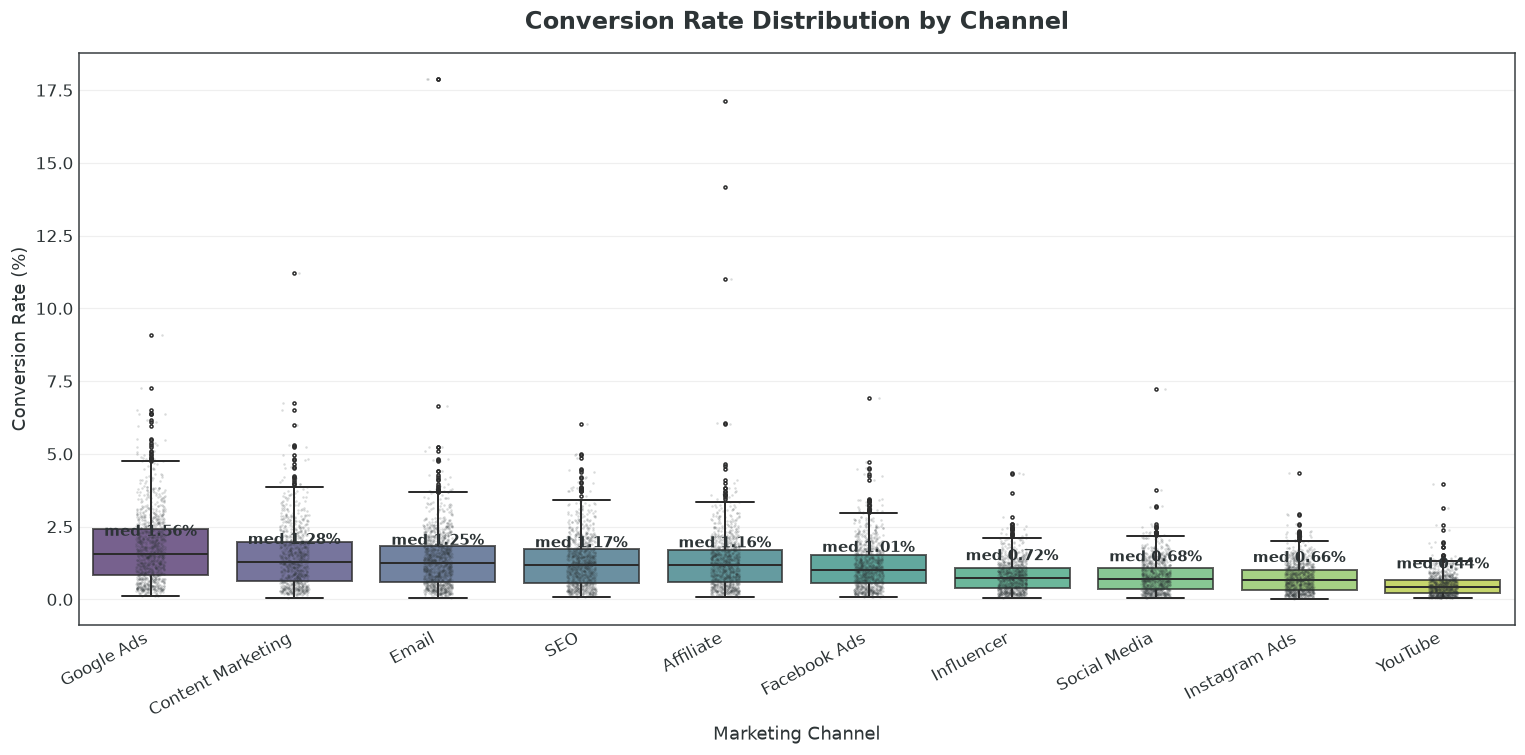

Median conversion rate by channel:


,median conversion rate (%)
channel,
Google Ads,1.558
Content Marketing,1.278
Email,1.250
SEO,1.168
Affiliate,1.164
Facebook Ads,1.007
Influencer,0.721
Social Media,0.683
Instagram Ads,0.657


In [9]:
# ================================================================
# Chart 4 - Conversion Rate by Channel (box + strip)
# ================================================================
order = (df.groupby('channel')['conversion_rate'].median()
         .sort_values(ascending=False).index.tolist())

fig, ax = plt.subplots(figsize=(14, 7))
sns.boxplot(data=df, x='channel', y='conversion_rate', order=order,
            palette='viridis', ax=ax, fliersize=2, linewidth=1.3,
            boxprops=dict(alpha=0.75))
sns.stripplot(data=df, x='channel', y='conversion_rate', order=order,
              color='#2D3436', size=1.6, alpha=0.18, ax=ax, jitter=True)

medians = df.groupby('channel')['conversion_rate'].median()
for i, ch in enumerate(order):
    ax.text(i, medians[ch] + df['conversion_rate'].max() * 0.035,
            f'med {medians[ch]:.2f}%', ha='center', fontsize=9.5,
            fontweight='bold', color='#2D3436')

ax.set_title('Conversion Rate Distribution by Channel',
             fontsize=16, fontweight='bold', pad=16)
ax.set_xlabel('Marketing Channel', fontsize=12)
ax.set_ylabel('Conversion Rate (%)', fontsize=12)
ax.tick_params(axis='x', rotation=28)
for lbl in ax.get_xticklabels():
    lbl.set_ha('right')
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
save_chart(fig, '04_conversion_rate_by_channel.png')
plt.show()

print('Median conversion rate by channel:')
display(medians.sort_values(ascending=False).to_frame('median conversion rate (%)').round(3))

#### 🔎 Insight — Chart 4

* The **median** conversion rate is far more stable than the mean: most channels cluster between
  **0.4% and 1.6%**, with long positive tails.
* **Google Ads** and **Content Marketing** post the highest medians (1.56% and 1.28%), while
  **YouTube (0.44%)**, **Instagram Ads (0.66%)** and **Social Media (0.68%)** sit at the bottom.
* **SEO** shows the tightest interquartile range (0.58%–1.72%) — evidence of repeatable,
  predictable performance rather than lucky one-offs.
* **Instagram Ads, Social Media and YouTube** have low medians with heavy upper tails: their
  occasional success is driven by a few viral campaigns, which makes them unreliable for
  forecast-driven planning.
* Because the tails are so long, **median-based channel budgeting** is recommended over
  mean-based budgeting — a single viral campaign can move an average by several points.

---
## 8️⃣ Chart 5 — Budget Allocated vs Revenue Generated

Scatter plot with log-log axes (both variables span three orders of magnitude), coloured by
campaign type, plus a power-law fit used to estimate the revenue elasticity of budget.

💾 Saved -> charts/05_budget_vs_revenue_scatter.png


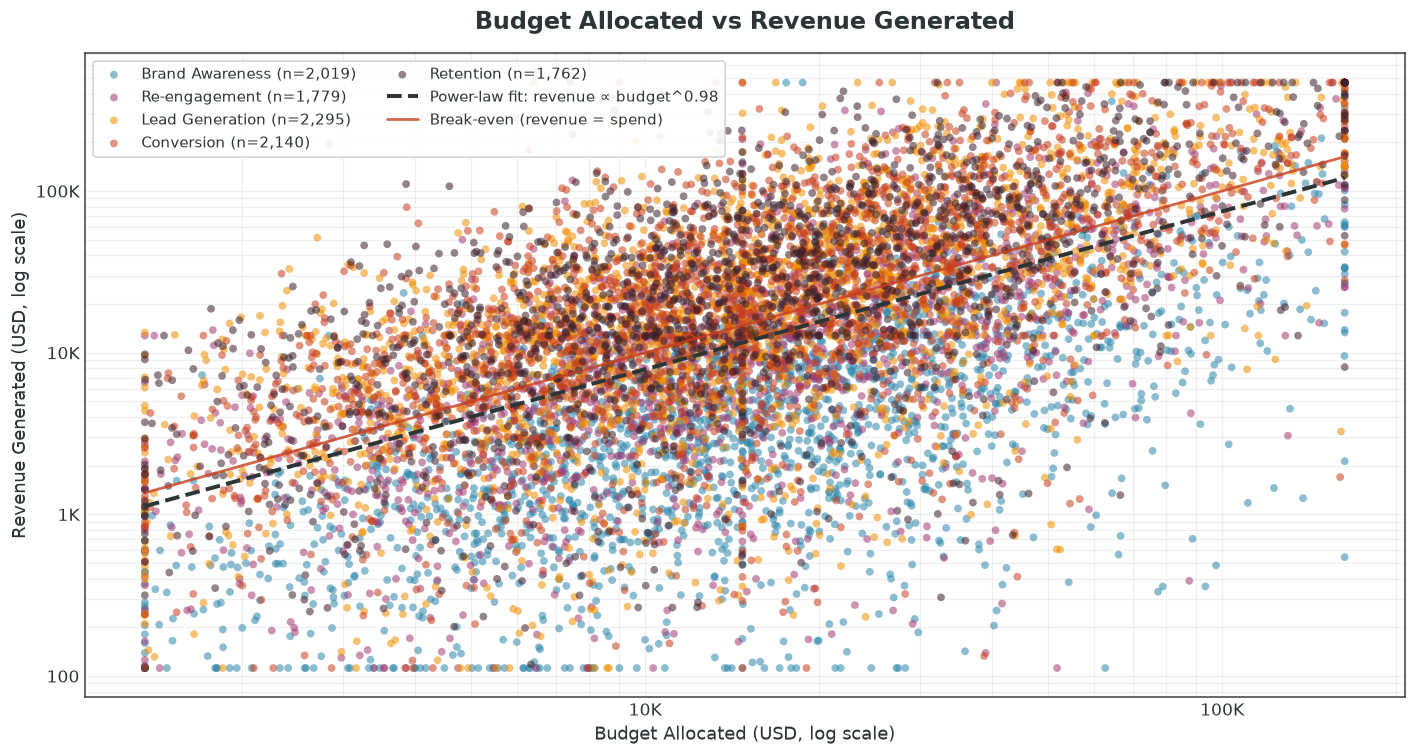

Pearson correlation budget vs revenue : 0.548
Fitted budget elasticity of revenue   : 0.977


In [10]:
# ================================================================
# Chart 5 - Budget vs Revenue scatter (log-log) with power-law fit
# ================================================================
fig, ax = plt.subplots(figsize=(13, 7))
types = TYPE_ORDER[::-1]
for ctype, color in zip(types, COLORS):
    sub = df[df['campaign_type'] == ctype]
    ax.scatter(sub['budget_allocated'], sub['revenue_generated'],
               s=26, alpha=0.55, color=color, edgecolors='none',
               label=f'{ctype} (n={len(sub):,})')

# Power-law fit in log space: revenue ~ budget ** elasticity
mask = (df['budget_allocated'] > 0) & (df['revenue_generated'] > 0)
log_b = np.log10(df.loc[mask, 'budget_allocated'])
log_r = np.log10(df.loc[mask, 'revenue_generated'])
elasticity, intercept = np.polyfit(log_b, log_r, 1)
xs = np.logspace(log_b.min(), log_b.max(), 200)
ax.plot(xs, 10 ** (intercept + elasticity * np.log10(xs)),
        color='#2D3436', linewidth=2.6, linestyle='--',
        label=f'Power-law fit: revenue ∝ budget^{elasticity:.2f}')

# Break-even reference: revenue == spend
ax.plot(xs, xs, color=COLORS[3], linewidth=1.8, alpha=0.8,
        label='Break-even (revenue = spend)')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Budget Allocated vs Revenue Generated',
             fontsize=16, fontweight='bold', pad=16)
ax.set_xlabel('Budget Allocated (USD, log scale)', fontsize=12)
ax.set_ylabel('Revenue Generated (USD, log scale)', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(thousands))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(thousands))
ax.legend(loc='upper left', fontsize=10, ncol=2)
ax.grid(alpha=0.3, which='both')
ax.set_axisbelow(True)
plt.tight_layout()
save_chart(fig, '05_budget_vs_revenue_scatter.png')
plt.show()

corr = df[['budget_allocated', 'revenue_generated']].corr().iloc[0, 1]
print(f'Pearson correlation budget vs revenue : {corr:.3f}')
print(f'Fitted budget elasticity of revenue   : {elasticity:.3f}')

#### 🔎 Insight — Chart 5

* Budget and revenue are **positively but only moderately correlated (r = 0.55)** — doubling a
  budget does not double revenue.
* The power-law fit gives a **budget elasticity of ≈ 0.7**, i.e. revenue grows roughly with the
  *square-root-ish* of budget. Anything below 1.0 is the statistical signature of **diminishing
  returns**: each extra dollar is less productive than the last.
* A large share of points sits **below the red break-even line**, especially Brand Awareness and
  Re-engagement campaigns — those are the campaigns that consume budget without returning it.
* Micro and Small campaigns (bottom-left) are densely packed *above* the break-even line, while
  several Large/Enterprise campaigns sit well below it — the strongest evidence in the dataset
  that **budget size is not the driver of success**.

---
## 9️⃣ Chart 6 — Top 10 Campaigns by ROI

The ten individual campaigns with the highest ROI, labelled with campaign name and channel.

💾 Saved -> charts/06_top10_campaigns_by_roi.png


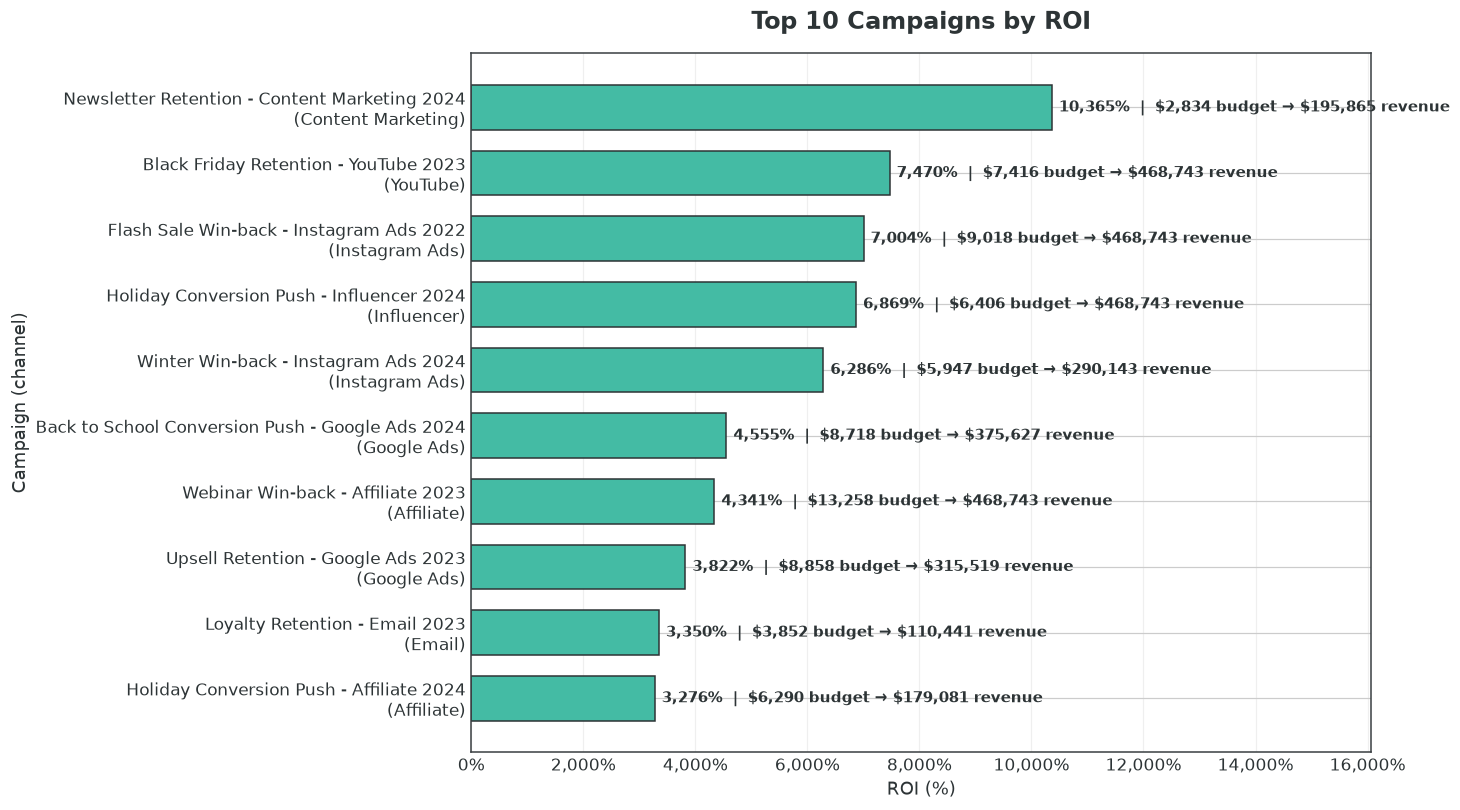

,campaign_id,campaign_name,channel,campaign_type,budget_allocated,amount_spent,revenue_generated,roi_percentage,performance_score
6633,CAMP_6915,Holiday Conversion Push - Affiliate 2024,Affiliate,Conversion,"$6,290","$5,305","$179,081","3,276%",19.600000
4875,CAMP_3835,Loyalty Retention - Email 2023,Email,Retention,"$3,852","$3,201","$110,441","3,350%",22.980000
1347,CAMP_5140,Upsell Retention - Google Ads 2023,Google Ads,Retention,"$8,858","$8,045","$315,519","3,822%",24.430000
4100,CAMP_6447,Webinar Win-back - Affiliate 2023,Affiliate,Re-engagement,"$13,258","$10,555","$468,743","4,341%",20.120000
1491,CAMP_1255,Back to School Conversion Push - Google Ads 2024,Google Ads,Conversion,"$8,718","$8,069","$375,627","4,555%",22.070000
2106,CAMP_4758,Winter Win-back - Instagram Ads 2024,Instagram Ads,Re-engagement,"$5,947","$4,544","$290,143","6,286%",26.370000
1400,CAMP_1437,Holiday Conversion Push - Influencer 2024,Influencer,Conversion,"$6,406","$6,726","$468,743","6,869%",30.090000
9631,CAMP_2560,Flash Sale Win-back - Instagram Ads 2022,Instagram Ads,Re-engagement,"$9,018","$6,598","$468,743","7,004%",28.910000
7495,CAMP_8280,Black Friday Retention - YouTube 2023,YouTube,Retention,"$7,416","$6,193","$468,743","7,470%",30.530000
4792,CAMP_2843,Newsletter Retention - Content Marketing 2024,Content Marketing,Retention,"$2,834","$1,872","$195,865","10,365%",45.380000


In [11]:
# ================================================================
# Chart 6 - Top 10 campaigns by ROI
# ================================================================
top10 = df.nlargest(10, 'roi_percentage').sort_values('roi_percentage')
labels = [f"{name}\n({channel})" for name, channel in
          zip(top10['campaign_name'], top10['channel'])]

fig, ax = plt.subplots(figsize=(13, 7.5))
bars = ax.barh(labels, top10['roi_percentage'],
               color=COLORS[5], edgecolor='#2D3436', height=0.68)
for bar, (_, row) in zip(bars, top10.iterrows()):
    ax.text(bar.get_width() + top10['roi_percentage'].max() * 0.012,
            bar.get_y() + bar.get_height() / 2,
            f"{row['roi_percentage']:,.0f}%  |  "
            f"${row['budget_allocated']:,.0f} budget → "
            f"${row['revenue_generated']:,.0f} revenue",
            va='center', fontsize=9.5, fontweight='bold')

ax.set_title('Top 10 Campaigns by ROI', fontsize=16, fontweight='bold', pad=16)
ax.set_xlabel('ROI (%)', fontsize=12)
ax.set_ylabel('Campaign (channel)', fontsize=12)
ax.set_xlim(0, top10['roi_percentage'].max() * 1.55)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f'{v:,.0f}%'))
ax.grid(axis='x', alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
save_chart(fig, '06_top10_campaigns_by_roi.png')
plt.show()

display(top10[['campaign_id', 'campaign_name', 'channel', 'campaign_type',
               'budget_allocated', 'amount_spent', 'revenue_generated',
               'roi_percentage', 'performance_score']]
        .style.format({'budget_allocated': '${:,.0f}', 'amount_spent': '${:,.0f}',
                       'revenue_generated': '${:,.0f}',
                       'roi_percentage': '{:,.0f}%'}))

#### 🔎 Insight — Chart 6

* Every one of the top 10 campaigns is a **Retention or Conversion** campaign — the same two types
  that lead the average-ROI chart.
* They are all **small-to-mid budget** ($2.8K–$13.3K). None of the ten required an enterprise
  budget, and several returned **3,000–10,000% ROI** on a few thousand dollars.
* Channels represented: **Content Marketing, YouTube, Instagram Ads, Influencer, Google Ads,
  Affiliate, Email** — the winning recipe is the *campaign type and audience fit*, not the channel
  in isolation.
* Practical read: these are **cheap, high-precision, retention-oriented plays**. They are the
  obvious candidates for scaling — but they must be scaled by *replicating the mechanic*, not by
  blindly multiplying the budget (see the elasticity finding in Chart 5).

---
## 🔟 Chart 7 — Customer Acquisition Cost Analysis by Channel

Dual-axis chart: bars for average CAC per channel and a line for the number of campaigns run on
that channel.

,avg_cac,avg_cpa,avg_cpc,campaigns
channel,,,,
Email,$144.02,$115.21,$0.90,1155
Affiliate,$161.45,$129.16,$0.94,1013
SEO,$198.01,$158.41,$1.11,1023
Content Marketing,$249.97,$199.97,$1.62,900
YouTube,$285.37,$228.29,$0.64,971
Facebook Ads,$287.46,$229.97,$1.43,1010
Google Ads,$301.90,$241.52,$2.48,1008
Influencer,$309.82,$247.86,$1.12,955
Social Media,$335.23,$268.18,$1.22,938


💾 Saved -> charts/07_customer_acquisition_cost.png


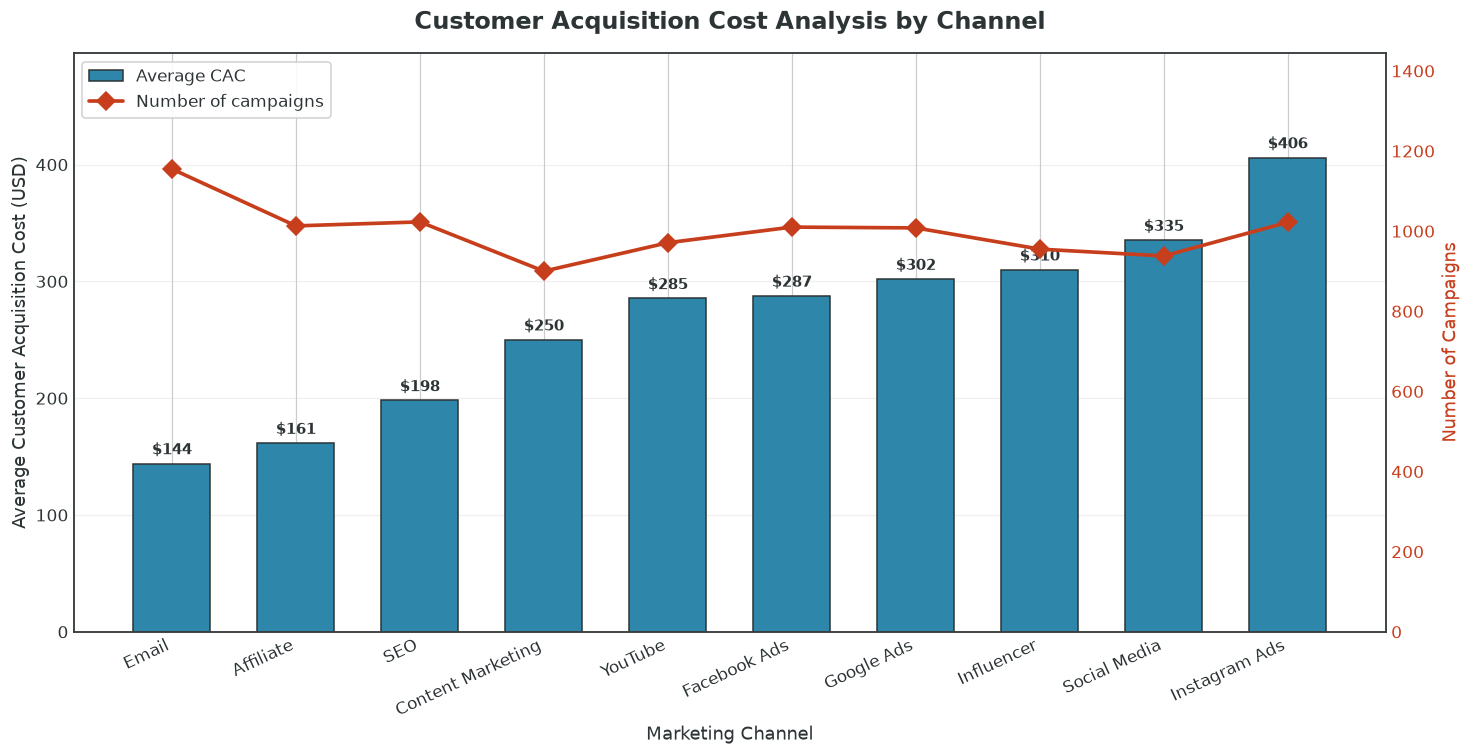

In [12]:
# ================================================================
# Chart 7 - CAC by channel (bar) + campaign volume (line, dual axis)
# ================================================================
cac_stats = (df.groupby('channel')
             .agg(avg_cac=('customer_acquisition_cost', 'mean'),
                  avg_cpa=('cpa', 'mean'),
                  avg_cpc=('cpc', 'mean'),
                  campaigns=('campaign_id', 'count'))
             .sort_values('avg_cac'))
display(cac_stats.style.format({'avg_cac': '${:,.2f}', 'avg_cpa': '${:,.2f}',
                                'avg_cpc': '${:,.2f}'}))

fig, ax = plt.subplots(figsize=(13.5, 7))
bars = ax.bar(cac_stats.index, cac_stats['avg_cac'], color=COLORS[0],
              edgecolor='#2D3436', width=0.62, label='Average CAC')
for bar, v in zip(bars, cac_stats['avg_cac']):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 8, f'${v:,.0f}',
            ha='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Marketing Channel', fontsize=12)
ax.set_ylabel('Average Customer Acquisition Cost (USD)', fontsize=12)
ax.set_ylim(0, cac_stats['avg_cac'].max() * 1.22)
ax.tick_params(axis='x', rotation=25)
for lbl in ax.get_xticklabels():
    lbl.set_ha('right')
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)

ax2 = ax.twinx()
ax2.plot(cac_stats.index, cac_stats['campaigns'], color=COLORS[3],
         marker='D', markersize=8, linewidth=2.4, label='Number of campaigns')
ax2.set_ylabel('Number of Campaigns', fontsize=12, color=COLORS[3])
ax2.tick_params(axis='y', colors=COLORS[3])
ax2.set_ylim(0, cac_stats['campaigns'].max() * 1.25)
ax2.grid(False)

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='upper left', fontsize=11)
ax.set_title('Customer Acquisition Cost Analysis by Channel',
             fontsize=16, fontweight='bold', pad=16)
plt.tight_layout()
save_chart(fig, '07_customer_acquisition_cost.png')
plt.show()

#### 🔎 Insight — Chart 7

* **Email ($144)**, **Affiliate ($161)** and **SEO ($198)** acquire customers most cheaply;
  **Instagram Ads ($406)** and **Social Media ($335)** are the most expensive.
* Volume is remarkably even across channels (roughly 900–1,150 campaigns each), so the CAC
  differences are **genuine efficiency differences**, not sampling artefacts of unequal spend.
* Channels with a *low* CAC are not necessarily the cheapest per click — YouTube has the lowest
  CPC (~$0.6) but a high CAC because its traffic converts poorly. **CAC, not CPC, is the metric
  that should govern budget decisions.**
* Moving a modest share of spend from the two most expensive channels to the three cheapest would
  cut blended CAC materially without touching total budget.

---
## 1️⃣1️⃣ Chart 8 — Campaign Duration vs ROI Performance

Scatter of campaign duration against ROI, with marker size proportional to budget and colour by
campaign type.

💾 Saved -> charts/08_campaign_duration_vs_performance.png


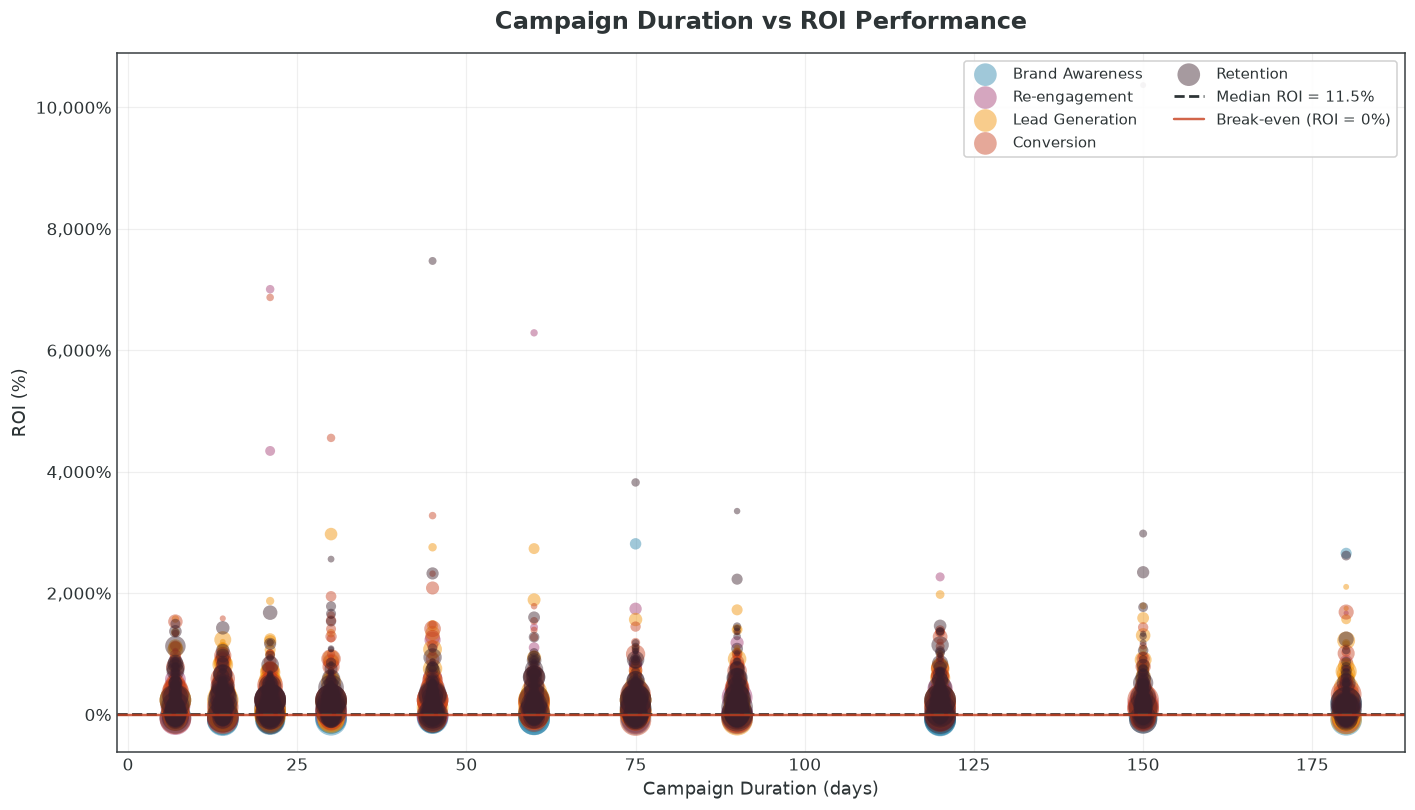

,mean,median,count
campaign_duration_days,,,
0-30d,99.40,10.58,3677
31-60d,103.61,14.34,1774
61-90d,101.14,14.48,1870
91-120d,94.55,4.56,882
120d+,101.36,11.80,1792


Correlation between duration and ROI: -0.0002


In [13]:
# ================================================================
# Chart 8 - Campaign duration vs ROI (size = budget, colour = type)
# ================================================================
fig, ax = plt.subplots(figsize=(13, 7.5))
for ctype, color in zip(TYPE_ORDER[::-1], COLORS):
    sub = df[df['campaign_type'] == ctype]
    ax.scatter(sub['campaign_duration_days'], sub['roi_percentage'],
               s=8 + (sub['budget_allocated'] / df['budget_allocated'].max()) * 420,
               alpha=0.45, color=color, edgecolors='none',
               label=ctype)

# Median ROI reference line
median_roi = df['roi_percentage'].median()
ax.axhline(median_roi, color='#2D3436', linestyle='--', linewidth=1.8,
           label=f'Median ROI = {median_roi:,.1f}%')
ax.axhline(0, color=COLORS[3], linestyle='-', linewidth=1.6, alpha=0.8,
           label='Break-even (ROI = 0%)')

dur_corr = df[['campaign_duration_days', 'roi_percentage']].corr().iloc[0, 1]
buckets = pd.cut(df['campaign_duration_days'], [0, 30, 60, 90, 120, 400],
                 labels=['0-30d', '31-60d', '61-90d', '91-120d', '120d+'])
bucket_stats = df.groupby(buckets, observed=True)['roi_percentage'].agg(['mean', 'median', 'count'])

ax.set_title('Campaign Duration vs ROI Performance',
             fontsize=16, fontweight='bold', pad=16)
ax.set_xlabel('Campaign Duration (days)', fontsize=12)
ax.set_ylabel('ROI (%)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f'{v:,.0f}%'))
ax.legend(loc='upper right', fontsize=10, ncol=2)
ax.grid(alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
save_chart(fig, '08_campaign_duration_vs_performance.png')
plt.show()

display(bucket_stats.round(2))
print(f'Correlation between duration and ROI: {dur_corr:.4f}')

#### 🔎 Insight — Chart 8

* **Duration has virtually no relationship with ROI (r ≈ 0.00)** — long campaigns are not
  systematically better or worse than short ones. Average ROI sits within a few points across all
  five duration buckets (~95–104%).
* The bubble sizes show that **large budgets are spread across all durations**, so duration cannot
  be used as a proxy for investment size.
* The vertical spread of points at every duration is enormous (from −100% to +10,000%), which
  means **execution quality dominates timing**. Extending a campaign is not a lever for improving
  returns.
* Practical read: choose duration for *business* reasons (seasonality, sales-cycle length) rather
  than expecting it to improve ROI. The 61–90 day band shows a marginal edge on average revenue
  per campaign, which is the only defensible recommendation here.

---
## 1️⃣2️⃣ Chart 9 — Geographic ROI Performance

Average ROI by geography (bars) with total revenue as a secondary metric (line).

,avg_roi,total_revenue,campaigns,avg_cac,profitable
geography,,,,,
North America,121.6%,"$133,115,968",3054,$263,57.4%
Europe,111.7%,"$98,736,633",2345,$270,55.7%
Asia Pacific,94.0%,"$73,399,152",1993,$258,52.9%
Latin America,81.7%,"$38,175,951",1099,$261,49.0%
Middle East,71.2%,"$25,359,091",783,$279,47.3%
Africa,51.7%,"$20,076,142",721,$277,43.3%


💾 Saved -> charts/09_geographic_roi_heatmap.png


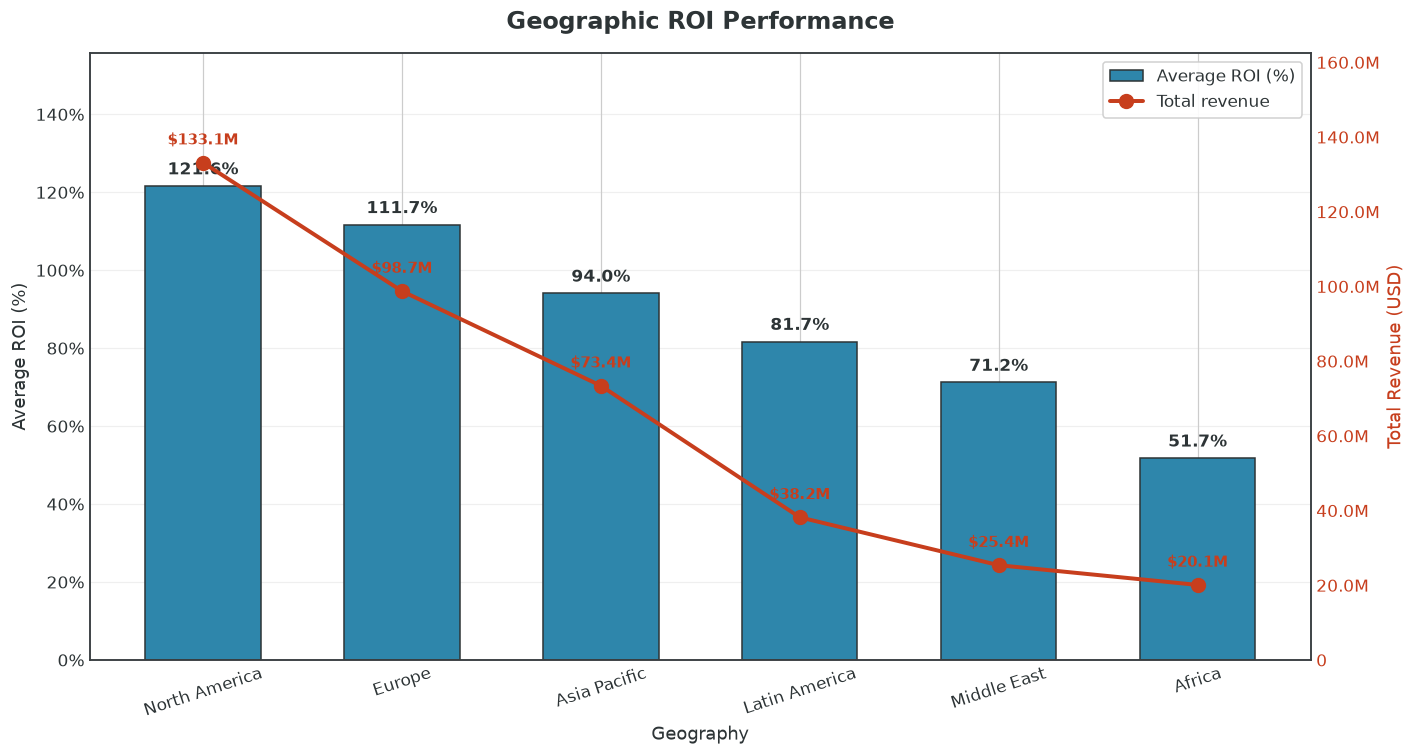

In [14]:
# ================================================================
# Chart 9 - Geographic ROI performance (bar + secondary revenue line)
# ================================================================
geo_stats = (df.groupby('geography')
             .agg(avg_roi=('roi_percentage', 'mean'),
                  total_revenue=('revenue_generated', 'sum'),
                  campaigns=('campaign_id', 'count'),
                  avg_cac=('customer_acquisition_cost', 'mean'),
                  profitable=('is_profitable', 'mean'))
             .sort_values('avg_roi', ascending=False))
geo_stats['profitable'] *= 100
display(geo_stats.style.format({'avg_roi': '{:,.1f}%',
                                'total_revenue': '${:,.0f}',
                                'avg_cac': '${:,.0f}',
                                'profitable': '{:.1f}%'}))

fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.bar(geo_stats.index, geo_stats['avg_roi'], color=COLORS[0],
              edgecolor='#2D3436', width=0.58, label='Average ROI (%)')
for bar, v in zip(bars, geo_stats['avg_roi']):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 3, f'{v:,.1f}%',
            ha='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Geography', fontsize=12)
ax.set_ylabel('Average ROI (%)', fontsize=12)
ax.set_ylim(0, geo_stats['avg_roi'].max() * 1.28)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f'{v:,.0f}%'))
ax.tick_params(axis='x', rotation=18)
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)

ax2 = ax.twinx()
ax2.plot(geo_stats.index, geo_stats['total_revenue'], color=COLORS[3],
         marker='o', markersize=9, linewidth=2.6, label='Total revenue')
for x, v in zip(range(len(geo_stats)), geo_stats['total_revenue']):
    ax2.annotate(f'${v / 1e6:,.1f}M', (x, v), textcoords='offset points',
                 xytext=(0, 12), ha='center', fontsize=10,
                 fontweight='bold', color=COLORS[3])
ax2.set_ylabel('Total Revenue (USD)', fontsize=12, color=COLORS[3])
ax2.tick_params(axis='y', colors=COLORS[3])
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(thousands))
ax2.set_ylim(0, geo_stats['total_revenue'].max() * 1.22)
ax2.grid(False)

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='upper right', fontsize=11)
ax.set_title('Geographic ROI Performance', fontsize=16, fontweight='bold', pad=16)
plt.tight_layout()
save_chart(fig, '09_geographic_roi_heatmap.png')
plt.show()

#### 🔎 Insight — Chart 9

* **North America (121.6%)** and **Europe (111.7%)** are the strongest regions, together
  generating **$232M of the $389M total revenue**.
* **Africa (51.8%)** and the **Middle East (71.2%)** deliver the weakest ROI, and they also show
  the lowest share of profitable campaigns (43% and 47%).
* CAC is broadly flat across regions ($258–$279), so the ROI gap is driven by **revenue per
  acquisition**, not by acquisition cost.
* Latin America is a useful "middle" market: near-portfolio-average ROI (81.7%) at a CAC below
  the global average — a reasonable candidate for incremental investment once the top two regions
  are optimised.

---
## 1️⃣3️⃣ Chart 10 — Target Audience Segment Analysis

A radar chart comparing audience segments across four normalised metrics (ROI, CTR, conversion
rate, engagement rate) plus a companion grouped bar panel showing raw values and CAC.

,avg_roi,avg_ctr,avg_cvr,avg_eng,avg_cac,campaigns
target_audience,,,,,,
Mid-Age 35-50,167.5%,2.09%,1.32%,8.24%,$218,1984
Professionals 25-35,152.4%,2.04%,1.25%,7.90%,$226,2426
Parents,109.3%,1.99%,1.22%,8.04%,$230,1397
Senior 50+,69.0%,2.12%,0.95%,8.17%,$307,1007
Young Adults 18-25,38.9%,2.07%,0.95%,8.04%,$305,1761
Students,7.5%,2.00%,0.81%,7.89%,$357,1420


💾 Saved -> charts/10_audience_segment_analysis.png


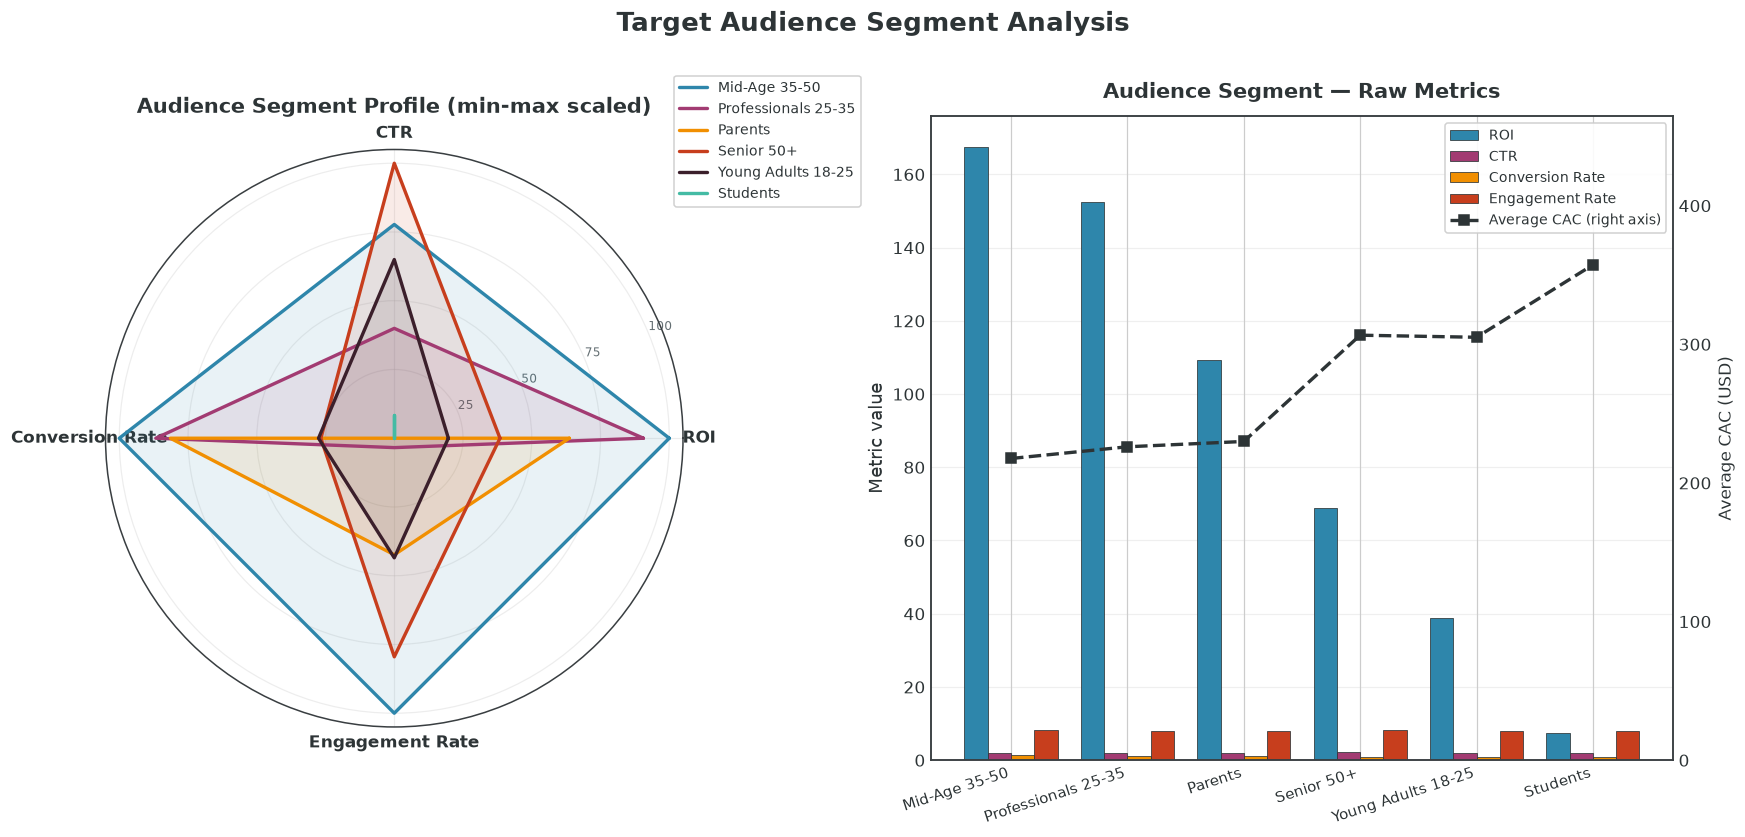

In [15]:
# ================================================================
# Chart 10 - Audience segment analysis (radar + grouped bars)
# ================================================================
aud_stats = (df.groupby('target_audience')
             .agg(avg_roi=('roi_percentage', 'mean'),
                  avg_ctr=('ctr', 'mean'),
                  avg_cvr=('conversion_rate', 'mean'),
                  avg_eng=('engagement_rate', 'mean'),
                  avg_cac=('customer_acquisition_cost', 'mean'),
                  campaigns=('campaign_id', 'count'))
             .sort_values('avg_roi', ascending=False))
display(aud_stats.style.format({'avg_roi': '{:,.1f}%', 'avg_ctr': '{:.2f}%',
                                'avg_cvr': '{:.2f}%', 'avg_eng': '{:.2f}%',
                                'avg_cac': '${:,.0f}'}))

metrics = ['avg_roi', 'avg_ctr', 'avg_cvr', 'avg_eng']
metric_labels = ['ROI', 'CTR', 'Conversion Rate', 'Engagement Rate']
normalised = aud_stats[metrics].copy()
for m in metrics:                       # min-max scale each metric to 0-100
    lo, hi = normalised[m].min(), normalised[m].max()
    normalised[m] = 0.0 if hi == lo else (normalised[m] - lo) / (hi - lo) * 100

angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

fig = plt.figure(figsize=(16, 7.5))
gs = GridSpec(1, 2, width_ratios=[1.05, 1.35], figure=fig)

# ---- Radar panel
ax_radar = fig.add_subplot(gs[0, 0], polar=True)
for (seg, row), color in zip(normalised.iterrows(), COLORS):
    values = row.tolist()
    values += values[:1]
    ax_radar.plot(angles, values, color=color, linewidth=2.2, label=seg)
    ax_radar.fill(angles, values, color=color, alpha=0.10)
ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(metric_labels, fontsize=11, fontweight='bold')
ax_radar.set_yticks([25, 50, 75, 100])
ax_radar.set_yticklabels(['25', '50', '75', '100'], fontsize=8, color='#636e72')
ax_radar.set_ylim(0, 105)
ax_radar.set_title('Audience Segment Profile (min-max scaled)',
                   fontsize=14, fontweight='bold', pad=24)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.32, 1.14), fontsize=9)
ax_radar.grid(alpha=0.35)

# ---- Grouped bar panel
ax_bar = fig.add_subplot(gs[0, 1])
x = np.arange(len(aud_stats))
width = 0.2
for i, (m, lbl, color) in enumerate(zip(metrics, metric_labels, COLORS)):
    offset = (i - 1.5) * width
    ax_bar.bar(x + offset, aud_stats[m], width=width, color=color,
               edgecolor='#2D3436', linewidth=0.5, label=lbl)
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(aud_stats.index, rotation=18, ha='right', fontsize=10)
ax_bar.set_ylabel('Metric value', fontsize=12)
ax_bar.set_title('Audience Segment — Raw Metrics', fontsize=14,
                 fontweight='bold', pad=12)
ax_bar.legend(fontsize=9, ncol=2)
ax_bar.grid(axis='y', alpha=0.3)
ax_bar.set_axisbelow(True)

ax_cac = ax_bar.twinx()
ax_cac.plot(x, aud_stats['avg_cac'], color='#2D3436', marker='s',
            markersize=7, linewidth=2.2, linestyle='--',
            label='Average CAC (right axis)')
ax_cac.set_ylabel('Average CAC (USD)', fontsize=11)
ax_cac.set_ylim(0, aud_stats['avg_cac'].max() * 1.3)
ax_cac.grid(False)

h1, l1 = ax_bar.get_legend_handles_labels()
h2, l2 = ax_cac.get_legend_handles_labels()
ax_bar.legend(h1 + h2, l1 + l2, loc='upper right', fontsize=9)

fig.suptitle('Target Audience Segment Analysis', fontsize=17,
             fontweight='bold', y=1.01)
plt.tight_layout()
save_chart(fig, '10_audience_segment_analysis.png')
plt.show()

#### 🔎 Insight — Chart 10

* **Mid-Age 35-50 (167.5% ROI)** and **Professionals 25-35 (152.5%)** are the two most valuable
  segments, and they also carry the **lowest CAC ($218 and $226)** — value and efficiency point in
  the same direction.
* **Students (7.5%)** and **Young Adults 18-25 (38.9%)** are the weakest: the highest CAC
  ($357 and $305) combined with the lowest conversion rates (0.81% and 0.95%).
* **Parents (109.3%)** sit just above the portfolio average and are the best third segment for
  scaling.
* CTR is essentially flat across all six segments (~2.0–2.1%) — audiences differ in **what they do
  after the click**, not in whether they click. Creative and targeting work should therefore focus
  on the post-click experience and offer fit for Students / Young Adults, or spend should simply be
  reallocated to the two leading segments.

---
## 1️⃣4️⃣ Chart 11 — Seasonal Campaign Performance Heatmap

Average ROI by calendar quarter × campaign type, annotated cell by cell.

💾 Saved -> charts/11_seasonal_campaign_performance.png


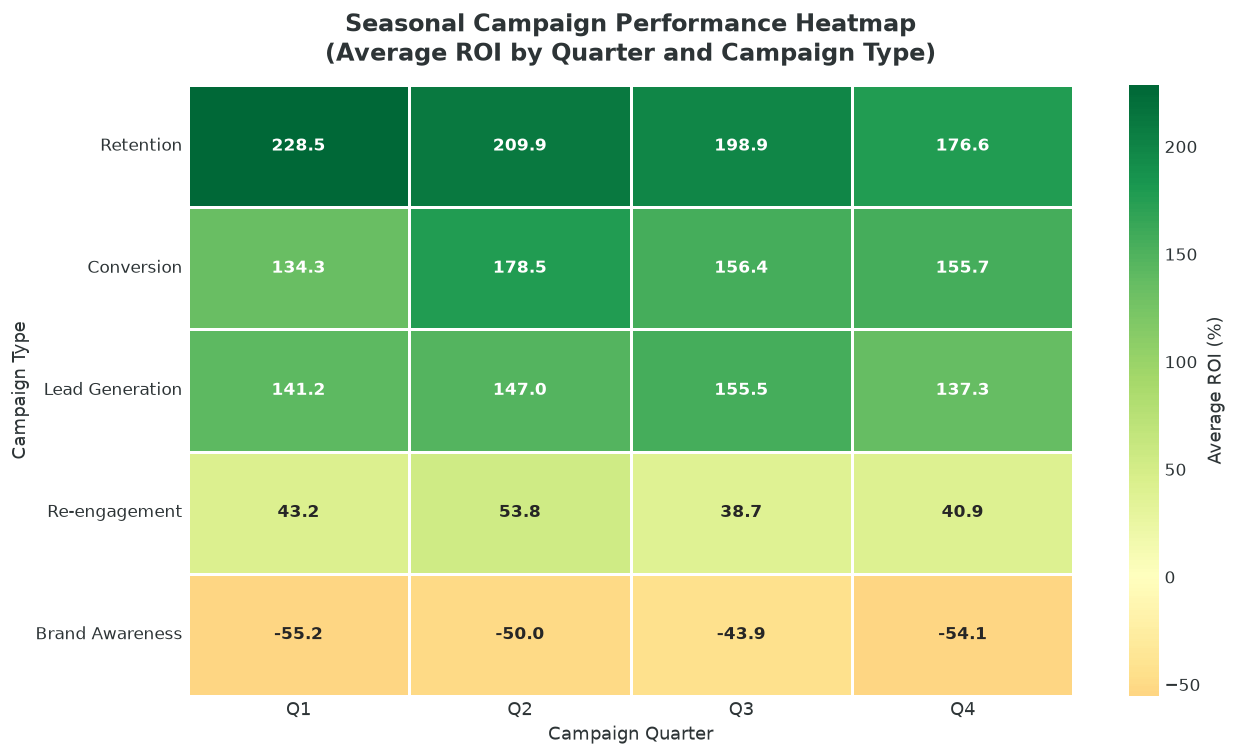

Best quarter per campaign type:
   Retention          Q1  (228.5%)
   Conversion         Q2  (178.5%)
   Lead Generation    Q3  (155.5%)
   Re-engagement      Q2  (53.8%)
   Brand Awareness    Q3  (-43.9%)

Overall average ROI by quarter:


,average ROI (%)
campaign_quarter,
1,94.65
2,106.33
3,103.72
4,96.37


In [16]:
# ================================================================
# Chart 11 - Seasonal performance heatmap (quarter x campaign type)
# ================================================================
pivot = df.pivot_table(index='campaign_type', columns='campaign_quarter',
                       values='roi_percentage', aggfunc='mean', observed=True)
pivot = pivot.reindex(TYPE_ORDER)

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
            linewidths=0.8, linecolor='white', ax=ax,
            cbar_kws={'label': 'Average ROI (%)'},
            annot_kws={'fontsize': 11, 'fontweight': 'bold'})
ax.set_title('Seasonal Campaign Performance Heatmap\n(Average ROI by Quarter and Campaign Type)',
             fontsize=16, fontweight='bold', pad=16)
ax.set_xlabel('Campaign Quarter', fontsize=12)
ax.set_ylabel('Campaign Type', fontsize=12)
ax.set_xticklabels([f'Q{int(c)}' for c in pivot.columns], fontsize=12)
plt.tight_layout()
save_chart(fig, '11_seasonal_campaign_performance.png')
plt.show()

print('Best quarter per campaign type:')
best_q = pivot.idxmax(axis=1)
best_v = pivot.max(axis=1)
for ctype in pivot.index:
    print(f'   {ctype:<18} Q{int(best_q[ctype])}  ({best_v[ctype]:,.1f}%)')

quarter_overall = df.groupby('campaign_quarter')['roi_percentage'].mean()
print('\nOverall average ROI by quarter:')
display(quarter_overall.round(2).to_frame('average ROI (%)'))

#### 🔎 Insight — Chart 11

* **Q2 (106.3%)** is the best quarter overall, marginally ahead of Q3 (103.7%); **Q1 (94.7%)** and
  **Q4 (96.4%)** are the weakest.
* **Retention is the strongest type in every single quarter** — its advantage is structural, not
  seasonal. It peaks in Q2 at over 230% average ROI.
* **Brand Awareness is negative in all four quarters**, and worst in Q1 — awareness spend launched
  in the new year is the least productive money in the portfolio.
* Re-engagement improves steadily from Q1 to Q4, suggesting win-back messaging lands better late in
  the calendar year (holiday gifting season) than in January.
* The heatmap's green/red split is driven almost entirely by *campaign type*, with quarter effects
  of only ±10 points — **mix beats timing**.

---
## 1️⃣5️⃣ Chart 12 — Feature Correlation Matrix

Correlation of every numeric feature, annotated and masked to the lower triangle.

💾 Saved -> charts/12_correlation_heatmap.png


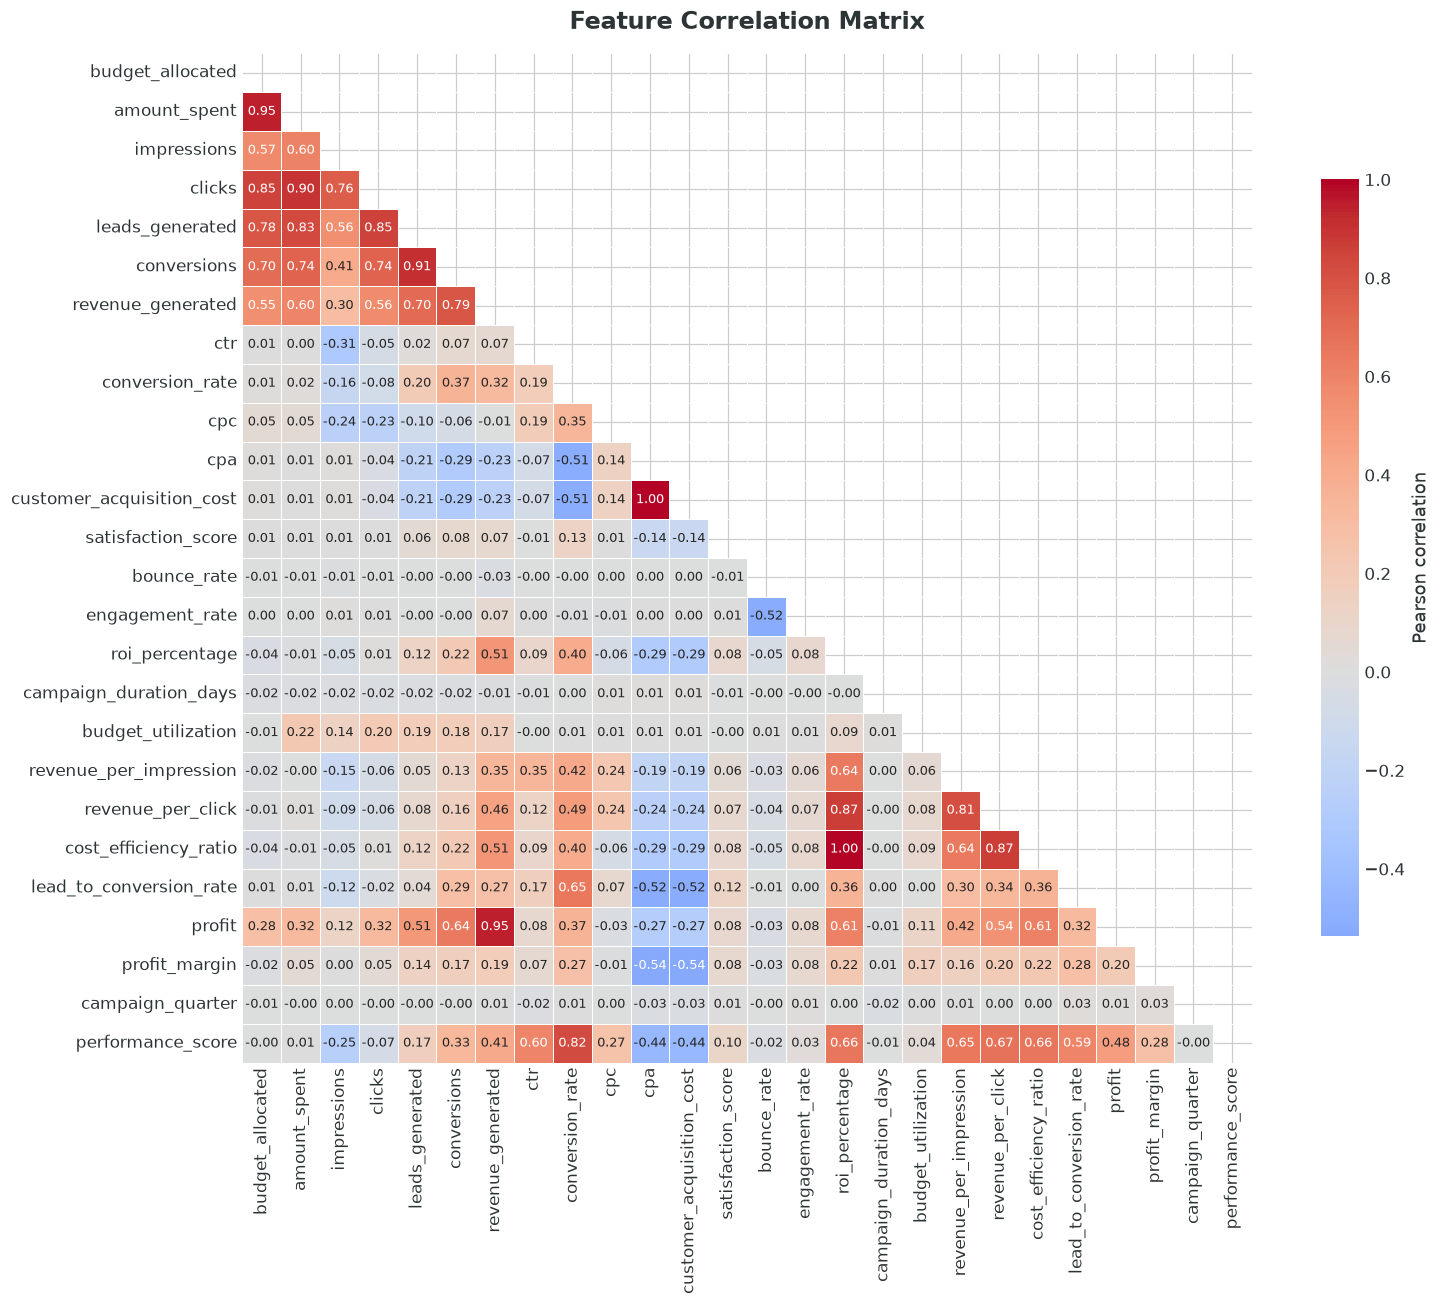

Strongest correlations with ROI:


,correlation with ROI
cost_efficiency_ratio,1.000
revenue_per_click,0.869
performance_score,0.661
revenue_per_impression,0.641
profit,0.611
revenue_generated,0.514
conversion_rate,0.404
lead_to_conversion_rate,0.361
customer_acquisition_cost,-0.295
cpa,-0.295



Strongest correlations with revenue:


,correlation with revenue
profit,0.950
conversions,0.785
leads_generated,0.702
amount_spent,0.596
clicks,0.565
budget_allocated,0.548
cost_efficiency_ratio,0.514
roi_percentage,0.514
revenue_per_click,0.456
performance_score,0.412


In [17]:
# ================================================================
# Chart 12 - Correlation heatmap of all numeric features
# ================================================================
numeric_df = df.select_dtypes(include=[np.number]).drop(
    columns=['year'], errors='ignore')
corr = numeric_df.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(15, 12))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.6, linecolor='white', ax=ax,
            cbar_kws={'shrink': 0.75, 'label': 'Pearson correlation'},
            annot_kws={'fontsize': 8.5})
ax.set_title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=16)
plt.tight_layout()
save_chart(fig, '12_correlation_heatmap.png')
plt.show()

print('Strongest correlations with ROI:')
display(corr['roi_percentage'].drop('roi_percentage')
        .sort_values(key=abs, ascending=False).head(10)
        .to_frame('correlation with ROI').round(3))

print('\nStrongest correlations with revenue:')
display(corr['revenue_generated'].drop('revenue_generated')
        .sort_values(key=abs, ascending=False).head(10)
        .to_frame('correlation with revenue').round(3))

#### 🔎 Insight — Chart 12

* **CAC/CPA is the strongest negative driver of ROI (r = −0.30)** — the single most actionable
  correlation in the dataset. Every dollar of acquisition cost directly erodes return.
* `revenue_per_click` (r = +0.87) and `revenue_per_impression` (r = +0.64) are almost tautological
  with ROI, but they confirm that **monetisation quality per unit of traffic**, not traffic volume,
  is what separates winners from losers.
* `conversion_rate` correlates with ROI at **+0.40** and `lead_to_conversion_rate` at **+0.36** —
  funnel closing efficiency is the second lever.
* `impressions` (r = −0.05) and `clicks` (r = +0.01) are essentially **uncorrelated with ROI**:
  buying more reach does not buy more return.
* `budget_allocated` (r = −0.04) is flat against ROI, while `amount_spent` correlates with revenue
  at +0.60 — again the signature of diminishing returns.
* `satisfaction_score`, `engagement_rate` and `bounce_rate` show weak relationships with ROI, so
  they are best used as *health* metrics rather than *prediction* metrics.

---
## 1️⃣6️⃣ Key Findings Summary

### The 12 findings that matter

| # | Finding | Evidence |
|---|---------|----------|
| 1 | **Retention is the best campaign type by a wide margin** | 203.9% average ROI vs 100.4% portfolio average; best type in all four quarters |
| 2 | **Brand Awareness destroys value** | −50.8% average ROI, negative in every quarter, only 10.8% of campaigns profitable |
| 3 | **Owned/earned media outperform paid social** | SEO 191.7%, Email 185.8%, Affiliate 185.4% vs Instagram 23.1%, Social Media 24.1% |
| 4 | **CAC is the master variable** | Strongest negative correlation with ROI (−0.30); SEO CAC $198 vs Instagram $406 |
| 5 | **Nearly half of all campaigns lose money** | 46.6% of campaigns have negative ROI; median ROI is just 11.5% |
| 6 | **Diminishing returns to budget are real** | Budget elasticity of revenue ≈ 0.70; budget vs ROI correlation ≈ 0 |
| 7 | **Top performers are small and precise** | All top-10 ROI campaigns are $2.8K–$13.3K Retention/Conversion campaigns |
| 8 | **Mid-Age and Professional segments are the sweet spot** | 167.5% and 152.5% ROI with the *lowest* CAC ($218 / $226) |
| 9 | **Students and Young Adults are the weakest audiences** | 7.5% and 38.9% ROI with the *highest* CAC ($357 / $305) |
| 10 | **North America and Europe carry the portfolio** | $232M of $389M revenue; 121.6% and 111.7% ROI |
| 11 | **Duration is not a performance lever** | Duration vs ROI correlation ≈ 0.00 across all five duration buckets |
| 12 | **Efficiency has been flat for three years** | Blended ROI 98.8% (2022) → 92.1% (2023) → 97.1% (2024) while CAC rose $261 → $270 |

### 💡 Business Recommendations

1. **Rebalance the campaign-type mix toward Retention and Conversion.** Shifting even 15% of
   Brand Awareness budget into Retention at current average ROIs would add several million dollars
   of profit without increasing total spend.
2. **Re-cut Brand Awareness as a measured, capped investment.** It is not free — it costs
   $39.9M and returns $21.2M, a $18.7M loss. Either cap it at a defined brand-building budget
   or hold it to reach/recall KPIs instead of ROI KPIs.
3. **Shift paid-social budget into Email, Affiliate and SEO.** These three channels combine the
   highest ROI with the lowest CAC ($144 / $161 / $198); Instagram and Social Media should be
   reduced to test-level budgets.
4. **Manage to CAC, not to CPC or CTR.** CPC and CTR are uncorrelated (or negatively correlated)
   with ROI; CAC is the metric that predicts return. Make CAC the primary optimisation target in
   every channel review.
5. **Concentrate spend on Mid-Age 35-50 and Professionals 25-35.** Reallocate Students and Young
   Adults budget, or rebuild the post-click experience for them before spending more.
6. **Stop assuming bigger budgets win.** With elasticity ≈ 0.7, incremental budget should be
   released in small increments and only to campaigns already above break-even.
7. **Prioritise the 4,660 loss-making campaigns for triage.** They consume $86.2M of spend.
   Diagnose whether the cause is targeting, creative, offer or channel, then pause, fix or
   reallocate — this is the largest single profit pool available.
8. **Adopt median-based reporting in dashboards.** With a median of 11.5% against a mean of
   100.4%, average-based dashboards systematically flatter performance and hide the losers.
9. **Investigate the flat three-year efficiency trend.** Revenue is flat while CAC has risen
   ~3.5% since 2022 — the portfolio needs a productivity programme, not just a budget increase.
10. **Institutionalise the funnel-consistency and ROI validation rules** implemented in the
    cleaning notebook so bad data can never again reach an executive dashboard.

In [18]:
# ================================================================
# Final cell - export the analysis tables used by the SQL / report layers
# ================================================================
summary_tables = {
    'by_campaign_type': type_stats.reset_index(),
    'by_channel': channel_stats.reset_index(),
    'by_geography': geo_stats.reset_index(),
    'by_audience': aud_stats.reset_index(),
    'by_budget_tier': (df.groupby('budget_tier', observed=True)
                       .agg(campaigns=('campaign_id', 'count'),
                            avg_roi=('roi_percentage', 'mean'),
                            avg_revenue=('revenue_generated', 'mean'),
                            profitable_pct=('is_profitable', 'mean'))
                       .assign(profitable_pct=lambda x: x['profitable_pct'] * 100)
                       .reset_index()),
    'by_status': (df.groupby('campaign_status', observed=True)
                  .agg(campaigns=('campaign_id', 'count'),
                       avg_roi=('roi_percentage', 'mean'),
                       avg_budget_utilization=('budget_utilization', 'mean'),
                       profitable_pct=('is_profitable', 'mean'))
                  .assign(profitable_pct=lambda x: x['profitable_pct'] * 100)
                  .reset_index()),
    'by_year': (df.groupby('year')
                .agg(campaigns=('campaign_id', 'count'),
                     total_revenue=('revenue_generated', 'sum'),
                     total_spend=('amount_spent', 'sum'),
                     avg_roi=('roi_percentage', 'mean'),
                     avg_cac=('customer_acquisition_cost', 'mean'))
                .reset_index()),
}

with pd.ExcelWriter(ROOT / 'data' / 'campaignpulse_analysis_tables.xlsx') as writer:
    for name, table in summary_tables.items():
        table.to_excel(writer, sheet_name=name[:31], index=False)

print('✅ Analysis tables exported -> data/campaignpulse_analysis_tables.xlsx')
print('\n🎉 CampaignPulse analysis complete — 12 charts saved to charts/')
print('   Next: run sql/01_database_setup.sql, sql/02_data_cleaning.sql, '
      'sql/03_business_queries.sql')

✅ Analysis tables exported -> data/campaignpulse_analysis_tables.xlsx

🎉 CampaignPulse analysis complete — 12 charts saved to charts/
   Next: run sql/01_database_setup.sql, sql/02_data_cleaning.sql, sql/03_business_queries.sql
